In [ ]:
!pip install geemap geopandas rasterio -q

import ee
import geemap
import geopandas as gpd
import pandas as pd
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 45.5 MB/s eta 0:00:00


In [ ]:
ee.Authenticate()

In [ ]:
EE_PROJECT = 'ner-landslide-sih'
ee.Initialize(project=EE_PROJECT)
print("Earth Engine initialized:", ee.String('Success!').getInfo())

Earth Engine initialized: Success!


In [ ]:
ner_states = [
    'Arunachal Pradesh', 'Assam', 'Manipur', 'Meghalaya',
    'Mizoram', 'Nagaland', 'Sikkim', 'Tripura'
]

# FAO GAUL level-1 = state/province boundaries
admin1 = ee.FeatureCollection('FAO/GAUL/2015/level1')

ner_fc = admin1.filter(ee.Filter.And(
    ee.Filter.eq('ADM0_NAME', 'India'),
    ee.Filter.inList('ADM1_NAME', ner_states)
))

print("States found:", ner_fc.aggregate_array('ADM1_NAME').getInfo())

ner_boundary = ner_fc.geometry()          # merged single geometry
ner_bbox = ner_boundary.bounds()          # bounding box, useful for clipping rasters later

States found: ['Assam', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Sikkim', 'Tripura', 'Arunachal Pradesh']


In [ ]:
Map = geemap.Map(center=[26, 93], zoom=6)
Map.addLayer(ner_fc, {'color': 'red'}, 'NER States')
Map

Map(center=[26, 93], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tran…

In [ ]:
# SRTM 30m Digital Elevation Model, clipped to NER
dem = ee.Image('USGS/SRTMGL1_003').clip(ner_boundary).rename('elevation')

slope = ee.Terrain.slope(dem).rename('slope')
aspect = ee.Terrain.aspect(dem).rename('aspect')

print("DEM, slope, aspect computed.")

DEM, slope, aspect computed.


In [ ]:
laplacian_kernel = ee.Kernel.laplacian8(normalize=False)
curvature = dem.convolve(laplacian_kernel).rename('curvature')

print("Curvature computed.")

Curvature computed.


In [ ]:
terrain_stack = dem.addBands([slope, aspect, curvature])

Map2 = geemap.Map(center=[26, 93], zoom=6)
Map2.addLayer(dem, {'min': 0, 'max': 3000, 'palette': ['green', 'yellow', 'brown', 'white']}, 'Elevation')
Map2.addLayer(slope, {'min': 0, 'max': 60, 'palette': ['white', 'orange', 'red']}, 'Slope', False)
Map2.addLayer(aspect, {'min': 0, 'max': 360}, 'Aspect', False)
Map2.addLayer(ner_fc, {'color': 'black'}, 'NER Boundary Outline')
Map2

Map(center=[26, 93], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tran…

In [ ]:
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11
    mask = qa.bitwiseAnd(cloud_bit_mask).eq(0).And(qa.bitwiseAnd(cirrus_bit_mask).eq(0))
    return image.updateMask(mask)

s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(ner_boundary)
      .filterDate('2022-01-01', '2024-12-31')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
      .map(mask_s2_clouds))

def add_ndvi(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return image.addBands(ndvi)

s2_ndvi = s2.map(add_ndvi)

# Long-term average NDVI (matches build guide's "static" requirement)
ndvi_mean = s2_ndvi.select('NDVI').mean().clip(ner_boundary).rename('ndvi')

print("NDVI computed.")

NDVI computed.


In [ ]:
# ESA WorldCover 10m — global, reliable, well-documented land cover classes
lulc = ee.ImageCollection('ESA/WorldCover/v200').first().clip(ner_boundary).rename('lulc')

print("LULC loaded. Classes: 10=Tree cover, 20=Shrubland, 30=Grassland, 40=Cropland,")
print("50=Built-up, 60=Bare/sparse veg, 80=Water, 90=Wetland, 95=Mangroves")

LULC loaded. Classes: 10=Tree cover, 20=Shrubland, 30=Grassland, 40=Cropland,
50=Built-up, 60=Bare/sparse veg, 80=Water, 90=Wetland, 95=Mangroves


In [ ]:
# CHIRPS daily rainfall — aggregate to long-term annual average (mm/year)
chirps = (ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')
          .filterBounds(ner_boundary)
          .filterDate('2015-01-01', '2025-01-01'))

# Sum rainfall per year, then average across years = mean annual rainfall
years = ee.List.sequence(2015, 2024)

def yearly_sum(y):
    y = ee.Number(y)
    start = ee.Date.fromYMD(y, 1, 1)
    end = start.advance(1, 'year')
    return chirps.filterDate(start, end).sum().set('year', y)

yearly_rainfall = ee.ImageCollection.fromImages(years.map(yearly_sum))
rainfall_mean = yearly_rainfall.mean().clip(ner_boundary).rename('rainfall')

print("Rainfall climatology computed.")

Rainfall climatology computed.


In [ ]:
feature_stack = (terrain_stack
                  .addBands(ndvi_mean)
                  .addBands(lulc)
                  .addBands(rainfall_mean))

print("Bands in feature stack:", feature_stack.bandNames().getInfo())

Map3 = geemap.Map(center=[26, 93], zoom=6)
Map3.addLayer(ndvi_mean, {'min': 0, 'max': 1, 'palette': ['brown', 'yellow', 'green']}, 'NDVI')
Map3.addLayer(lulc, {}, 'LULC', False)
Map3.addLayer(rainfall_mean, {'min': 500, 'max': 4000, 'palette': ['white', 'blue', 'darkblue']}, 'Rainfall', False)
Map3.addLayer(ner_fc, {'color': 'black'}, 'NER Boundary', True)
Map3

Bands in feature stack: ['elevation', 'slope', 'aspect', 'curvature', 'ndvi', 'lulc', 'rainfall']


Map(center=[26, 93], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tran…

In [ ]:
# NASA Global Landslide Catalog
landslides_all = ee.FeatureCollection(
    "projects/sat-io/open-datasets/events/global_landslide_1970-2019"
)

# Keep only landslides inside NER
landslides_ner = landslides_all.filterBounds(ner_boundary)

print("NER landslide records:",
      landslides_ner.size().getInfo())

NER landslide records: 398


In [ ]:
# Look at the first landslide record
first_landslide = landslides_ner.first()

print(first_landslide.toDictionary().getInfo())

{'admin_divi': '', 'country_co': '', 'country_na': '', 'created_da': '12/20/2017 04:36:00 PM', 'event_date': '07/10/2017 12:55:00 PM', 'event_desc': 'Many vehicles plying along the Rongey/Chongey road were crushed by a major landslide at Maney Khola Rongay, East Sikkim. According to reports posted by the Sikkim Police in facebook on Wednesday, Rongey/Chongey road was blocked at Maney Khola due to rock', 'event_id': 11183, 'event_impo': '', 'event_time': '', 'event_titl': 'Cars crushed by deadly landslide on Chongey road, Sikkim', 'fatality_c': 0, 'gazeteer_c': '', 'injury_cou': 0, 'landslid_1': '', 'landslid_2': 'medium', 'landslid_3': '', 'landslide_': 'rock_fall', 'last_edite': '02/15/2018 03:51:00 PM', 'latitude': 27.360364, 'location_a': '100km', 'location_d': 'East Sikkim', 'longitude': 88.651914, 'notes': 'Cannot find location of Maney Khola Rongay', 'photo_link': 'https://static.thenortheasttoday.com/wp-content/uploads/2016/09/land1.jpg', 'source_lin': 'https://thenortheasttoday

In [ ]:
Map4 = geemap.Map(center=[26, 93], zoom=6)

Map4.addLayer(
    ndvi_mean,
    {
        'min': 0,
        'max': 1,
        'palette': ['brown', 'yellow', 'green']
    },
    'NDVI'
)

Map4.addLayer(
    landslides_ner,
    {
        'color': 'red'
    },
    'Historical Landslides'
)

Map4.addLayer(
    ner_fc,
    {
        'color': 'black'
    },
    'NER Boundary'
)

Map4

Map(center=[26, 93], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tran…

In [ ]:
positive_points = landslides_ner.map(
    lambda feature: feature.set('label', 1)
)

print(
    "Positive samples:",
    positive_points.size().getInfo()
)

Positive samples: 398


In [ ]:
print(
    positive_points.aggregate_histogram('label').getInfo()
)

{'1': 398}


In [ ]:
positive_samples = feature_stack.sampleRegions(
    collection=positive_points,
    properties=['label'],
    scale=30,
    geometries=True
)

print(
    "Positive training records:",
    positive_samples.size().getInfo()
)

Positive training records: 398


In [ ]:
print(
    positive_samples.first().getInfo()
)

{'type': 'Feature', 'geometry': {'geodesic': False, 'type': 'Point', 'coordinates': [88.65187152622764, 27.36043694534076]}, 'id': '00000000000000000c1f_0', 'properties': {'aspect': 201.6727294921875, 'curvature': -78, 'elevation': 2277, 'label': 1, 'lulc': 10, 'ndvi': 0.46504485607147217, 'rainfall': 1067.4358457839116, 'slope': 30.636198043823242}}


In [ ]:
landslide_buffer = positive_points.geometry().buffer(500)

print("Landslide exclusion zone created.")

Landslide exclusion zone created.


In [ ]:
# Candidate background area:
# inside NER
# outside 500 m landslide buffers
# slope greater than 5 degrees

background_area = (
    ee.Image.constant(1)
    .updateMask(slope.gt(5))
    .clip(ner_boundary)
    .updateMask(
        ee.Image.constant(1)
        .clip(landslide_buffer)
        .unmask(0)
        .Not()
    )
)

print("Background sampling area prepared.")

Background sampling area prepared.


In [ ]:
# Generate approximately 2 background samples
# for every positive sample

background_points_raw = background_area.sample(
    region=ner_boundary,
    scale=30,
    numPixels=796,
    seed=42,
    geometries=True
)

print(
    "Background candidates:",
    background_points_raw.size().getInfo()
)

Background candidates: 0


In [ ]:
distance_to_landslide = positive_points.distance(
    searchRadius=5000,
    maxError=50
)

print("Distance image created.")

Distance image created.


In [ ]:
# Keep locations:
# 1. inside NER
# 2. slope > 5 degrees
# 3. at least 500 m away from known landslides

background_area = (
    ee.Image.constant(1)
    .clip(ner_boundary)
    .updateMask(slope.gt(5))
    .updateMask(distance_to_landslide.gt(500))
)

print("Background sampling area prepared.")

Background sampling area prepared.


In [ ]:
Map6 = geemap.Map(center=[26, 93], zoom=6)

Map6.addLayer(
    background_area,
    {'min': 0, 'max': 1, 'palette': ['white', 'green']},
    'Background Sampling Area'
)

Map6.addLayer(
    landslides_ner,
    {'color': 'red'},
    'Historical Landslides'
)

Map6.addLayer(
    ner_fc,
    {'color': 'black'},
    'NER Boundary'
)

Map6

Map(center=[26, 93], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tran…

In [ ]:
background_points_raw = background_area.sample(
    region=ner_boundary,
    scale=30,
    numPixels=796,
    seed=42,
    geometries=True
)

print(
    "Background candidates:",
    background_points_raw.size().getInfo()
)

Background candidates: 70


In [ ]:
landslide_exclusion = positive_points.geometry().buffer(
    distance=500,
    maxError=50
)

# Start with the entire NER and exclude:
# 1. flat terrain (slope <= 5°)
# 2. 500 m around known landslides

background_mask = (
    ee.Image.constant(1)
    .clip(ner_boundary)
    .updateMask(slope.gt(5))
    .updateMask(
        ee.Image.constant(1)
        .paint(landslide_exclusion, 0)
        .eq(1)
    )
)

print("Final background mask created.")

Final background mask created.


In [ ]:
Map7 = geemap.Map(center=[26, 93], zoom=6)

Map7.addLayer(
    background_mask,
    {
        'min': 0,
        'max': 1,
        'palette': ['white', 'green']
    },
    'Valid Background Area'
)

Map7.addLayer(
    landslides_ner,
    {
        'color': 'red'
    },
    'Historical Landslides'
)

Map7.addLayer(
    ner_fc,
    {
        'color': 'black'
    },
    'NER Boundary'
)

Map7

Map(center=[26, 93], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tran…

In [ ]:
background_points_raw = background_mask.sample(
    region=ner_boundary,
    scale=30,
    numPixels=796,
    seed=42,
    geometries=True
)

print(
    "Background candidates:",
    background_points_raw.size().getInfo()
)

Background candidates: 512


In [ ]:
background_points = background_points_raw.map(
    lambda feature: feature.set('label', 0)
)

print(
    "Background samples:",
    background_points.size().getInfo()
)

Background samples: 512


In [ ]:
print(
    "Background label distribution:",
    background_points.aggregate_histogram('label').getInfo()
)

Background label distribution: {'0': 512}


In [ ]:
training_points = positive_points.merge(
    background_points
)

print(
    "Total training points:",
    training_points.size().getInfo()
)

Total training points: 910


In [ ]:
print(
    "Class distribution:",
    training_points.aggregate_histogram('label').getInfo()
)

Class distribution: {'0': 512, '1': 398}


In [ ]:
training_samples = feature_stack.sampleRegions(
    collection=training_points,
    properties=['label'],
    scale=30,
    geometries=True,
    tileScale=4
)

print(
    "Training samples after feature extraction:",
    training_samples.size().getInfo()
)

Training samples after feature extraction: 910


In [ ]:
first_training = training_samples.first()

print(
    first_training.toDictionary().getInfo()
)

{'aspect': 201.6727294921875, 'curvature': -78, 'elevation': 2277, 'label': 1, 'lulc': 10, 'ndvi': 0.46504485607147217, 'rainfall': 1067.4358457839116, 'slope': 30.636198043823242}


In [ ]:
training_df = geemap.ee_to_df(training_samples)

print("Dataset shape:", training_df.shape)

display(training_df.head())

Dataset shape: (910, 8)


,aspect,curvature,elevation,label,lulc,ndvi,rainfall,slope
0,201.672729,-78,2277,1,10,0.465045,1067.435846,30.636198
1,283.545319,8,1067,1,10,0.648151,2146.053962,19.063906
2,261.487122,-15,1367,1,60,0.146611,1929.161141,6.240689
3,337.296112,-1,1260,1,50,0.149631,2128.921086,15.682612
4,234.144165,-4,886,1,50,0.224563,2146.053962,22.516018


In [ ]:
print("========== DATASET INFO ==========")

print("\nShape:")
print(training_df.shape)

print("\nColumns:")
print(training_df.columns.tolist())

print("\nMissing values:")
print(training_df.isnull().sum())

print("\nClass distribution:")
print(training_df['label'].value_counts())

print("\nData types:")
print(training_df.dtypes)

========== DATASET INFO ==========

Shape:
(910, 8)

Columns:
['aspect', 'curvature', 'elevation', 'label', 'lulc', 'ndvi', 'rainfall', 'slope']

Missing values:
aspect       0
curvature    0
elevation    0
label        0
lulc         0
ndvi         0
rainfall     0
slope        0
dtype: int64

Class distribution:
label
0    512
1    398
Name: count, dtype: int64

Data types:
aspect       float64
curvature      int64
elevation      int64
label          int64
lulc           int64
ndvi         float64
rainfall     float64
slope        float64
dtype: object


In [ ]:
training_df.describe()

,aspect,curvature,elevation,label,lulc,ndvi,rainfall,slope
count,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000
mean,179.492774,-0.896703,937.046154,0.437363,18.450549,0.596595,2104.096474,18.958370
std,103.056422,24.990434,853.702112,0.496334,16.521323,0.210837,615.642830,11.095237
min,0.000000,-132.000000,23.000000,0.000000,10.000000,-0.502490,658.492169,0.000000
25%,92.575792,-14.000000,286.500000,0.000000,10.000000,0.485198,1694.491068,10.096818
50%,180.000000,-1.000000,788.500000,0.000000,10.000000,0.670423,1968.747045,17.512731
75%,267.944397,12.000000,1329.500000,1.000000,10.000000,0.753490,2480.657979,26.681972
max,358.019836,112.000000,5356.000000,1.000000,100.000000,0.886563,4646.057389,58.610130


In [ ]:
training_df.groupby('label')[
    ['elevation', 'slope', 'aspect', 'curvature', 'ndvi', 'rainfall']
].mean()

,elevation,slope,aspect,curvature,ndvi,rainfall
label,,,,,,
0,944.259766,20.153013,184.859588,0.359375,0.677059,2216.601415
1,927.766332,17.421541,172.588733,-2.512563,0.493084,1959.366498


In [ ]:
training_df.groupby('label')[
    ['elevation', 'slope', 'aspect', 'curvature', 'ndvi', 'rainfall']
].median()

,elevation,slope,aspect,curvature,ndvi,rainfall
label,,,,,,
0,720.0,19.038764,187.342232,0.0,0.721079,2100.189922
1,884.5,15.585137,173.589165,-2.0,0.517181,1841.383610


In [ ]:
pd.crosstab(
    training_df['lulc'],
    training_df['label'],
    normalize='columns'
)

label,0,1
lulc,,
10,0.867188,0.608040
30,0.078125,0.097990
40,0.023438,0.042714
50,0.000000,0.231156
60,0.009766,0.017588
70,0.001953,0.000000
80,0.005859,0.002513
90,0.001953,0.000000
100,0.011719,0.000000


In [ ]:
training_df[
    ['elevation', 'slope', 'aspect',
     'curvature', 'ndvi', 'lulc',
     'rainfall', 'label']
].corr()

,elevation,slope,aspect,curvature,ndvi,lulc,rainfall,label
elevation,1.000000,0.336113,0.006587,0.012840,-0.266136,0.255750,-0.494711,-0.009589
slope,0.336113,1.000000,0.003887,-0.002728,0.249463,-0.214543,-0.235095,-0.122190
aspect,0.006587,0.003887,1.000000,-0.067536,0.039277,-0.048156,-0.000230,-0.059098
curvature,0.012840,-0.002728,-0.067536,1.000000,0.017670,0.015816,-0.005450,-0.057039
ndvi,-0.266136,0.249463,0.039277,0.017670,1.000000,-0.755558,0.259413,-0.433098
lulc,0.255750,-0.214543,-0.048156,0.015816,-0.755558,1.000000,-0.203029,0.271896
rainfall,-0.494711,-0.235095,-0.000230,-0.005450,0.259413,-0.203029,1.000000,-0.207384
label,-0.009589,-0.122190,-0.059098,-0.057039,-0.433098,0.271896,-0.207384,1.000000


In [ ]:
def add_coordinates(feature):
    coords = feature.geometry().coordinates()

    return feature.set({
        'longitude': coords.get(0),
        'latitude': coords.get(1)
    })


training_samples_geo = training_samples.map(add_coordinates)

print(
    "Samples with coordinates:",
    training_samples_geo.size().getInfo()
)

Samples with coordinates: 910


In [ ]:
training_df = geemap.ee_to_df(training_samples_geo)

print("Dataset shape:", training_df.shape)

print("\nColumns:")
print(training_df.columns.tolist())

display(training_df.head())

Dataset shape: (910, 10)

Columns:
['aspect', 'curvature', 'elevation', 'label', 'latitude', 'longitude', 'lulc', 'ndvi', 'rainfall', 'slope']


,aspect,curvature,elevation,label,latitude,longitude,lulc,ndvi,rainfall,slope
0,201.672729,-78,2277,1,27.360437,88.651872,10,0.465045,1067.435846,30.636198
1,283.545319,8,1067,1,23.726033,92.717736,10,0.648151,2146.053962,19.063906
2,261.487122,-15,1367,1,26.092465,94.257628,60,0.146611,1929.161141,6.240689
3,337.296112,-1,1260,1,26.324769,94.514726,50,0.149631,2128.921086,15.682612
4,234.144165,-4,886,1,23.733579,92.747381,50,0.224563,2146.053962,22.516018


In [ ]:
print("Latitude range:")
print(training_df['latitude'].min(),
      training_df['latitude'].max())

print("\nLongitude range:")
print(training_df['longitude'].min(),
      training_df['longitude'].max())

Latitude range:
22.150298128975948 28.18967178411149

Longitude range:
88.0511680957369 96.99245944469214


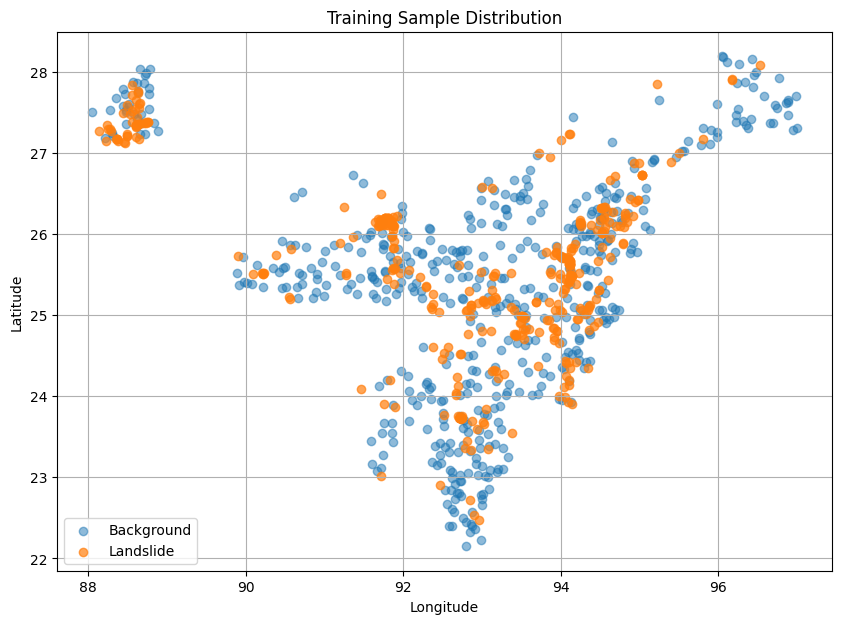

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.scatter(
    training_df.loc[training_df['label'] == 0, 'longitude'],
    training_df.loc[training_df['label'] == 0, 'latitude'],
    label='Background',
    alpha=0.5
)

plt.scatter(
    training_df.loc[training_df['label'] == 1, 'longitude'],
    training_df.loc[training_df['label'] == 1, 'latitude'],
    label='Landslide',
    alpha=0.7
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Training Sample Distribution')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# ==========================================
# CREATE SPATIAL BLOCKS
# ==========================================

BLOCK_SIZE = 1.0  # degrees

training_df['lat_block'] = (
    training_df['latitude'] // BLOCK_SIZE
).astype(int)

training_df['lon_block'] = (
    training_df['longitude'] // BLOCK_SIZE
).astype(int)

training_df['spatial_block'] = (
    training_df['lat_block'].astype(str)
    + "_"
    + training_df['lon_block'].astype(str)
)

print(
    "Number of spatial blocks:",
    training_df['spatial_block'].nunique()
)

print(
    "\nSamples per block:"
)

print(
    training_df['spatial_block'].value_counts().head(15)
)

Number of spatial blocks: 29

Samples per block:
spatial_block
25_94    104
27_88     78
26_94     76
24_93     62
25_93     61
23_92     60
26_91     59
25_92     55
25_91     54
24_94     40
25_90     36
24_92     35
22_92     30
27_96     27
26_93     25
Name: count, dtype: int64


In [ ]:
block_class = pd.crosstab(
    training_df['spatial_block'],
    training_df['label']
)

print(block_class.head(20))

label           0   1
spatial_block        
22_92          26   4
22_93           3   0
23_91          11   3
23_92          38  22
23_93          19   5
23_94           2   3
24_91           3   2
24_92          22  13
24_93          26  36
24_94          25  15
25_89           4   1
25_90          26  10
25_91          37  17
25_92          37  18
25_93          29  32
25_94          42  62
26_90           2   0
26_91           9  50
26_92           8   0
26_93          22   3


In [ ]:
block_summary = (
    training_df
    .groupby('spatial_block')['label']
    .agg(
        samples='count',
        landslides='sum'
    )
)

block_summary['background'] = (
    block_summary['samples'] -
    block_summary['landslides']
)

block_summary['landslide_ratio'] = (
    block_summary['landslides'] /
    block_summary['samples']
)

block_summary = block_summary.sort_index()

display(block_summary)

,samples,landslides,background,landslide_ratio
spatial_block,,,,
22_92,30,4,26,0.133333
22_93,3,0,3,0.000000
23_91,14,3,11,0.214286
23_92,60,22,38,0.366667
23_93,24,5,19,0.208333
23_94,5,3,2,0.600000
24_91,5,2,3,0.400000
24_92,35,13,22,0.371429
24_93,62,36,26,0.580645


In [ ]:
# Candidate blocks for testing
candidate_test_blocks = block_summary[
    (block_summary['samples'] >= 15) &
    (block_summary['landslides'] > 0) &
    (block_summary['background'] > 0)
]

print("Candidate test blocks:")
display(candidate_test_blocks)

Candidate test blocks:


,samples,landslides,background,landslide_ratio
spatial_block,,,,
22_92,30,4,26,0.133333
23_92,60,22,38,0.366667
23_93,24,5,19,0.208333
24_92,35,13,22,0.371429
24_93,62,36,26,0.580645
24_94,40,15,25,0.375000
25_90,36,10,26,0.277778
25_91,54,17,37,0.314815
25_92,55,18,37,0.327273


In [ ]:
test_blocks = [
    '23_92',
    '25_94',
    '27_88'
]

# Test = held-out spatial blocks
test_df = training_df[
    training_df['spatial_block'].isin(test_blocks)
].copy()

# Train = all remaining spatial blocks
train_df = training_df[
    ~training_df['spatial_block'].isin(test_blocks)
].copy()

print("========== TRAINING SET ==========")
print("Samples:", len(train_df))
print("\nClass distribution:")
print(train_df['label'].value_counts())

print("\n========== TEST SET ==========")
print("Samples:", len(test_df))
print("\nClass distribution:")
print(test_df['label'].value_counts())

print("\n========== TEST BLOCKS ==========")
print(test_df['spatial_block'].unique())

========== TRAINING SET ==========
Samples: 668

Class distribution:
label
0    401
1    267
Name: count, dtype: int64

========== TEST SET ==========
Samples: 242

Class distribution:
label
1    131
0    111
Name: count, dtype: int64

========== TEST BLOCKS ==========
['27_88' '23_92' '25_94']


In [ ]:
train_blocks = set(train_df['spatial_block'].unique())
test_blocks_set = set(test_df['spatial_block'].unique())

overlap = train_blocks.intersection(test_blocks_set)

print("Training spatial blocks:", len(train_blocks))
print("Testing spatial blocks:", len(test_blocks_set))
print("Overlapping blocks:", overlap)

if len(overlap) == 0:
    print("\n✅ NO SPATIAL LEAKAGE")
else:
    print("\n❌ SPATIAL LEAKAGE DETECTED")

Training spatial blocks: 26
Testing spatial blocks: 3
Overlapping blocks: set()

✅ NO SPATIAL LEAKAGE


In [ ]:
feature_columns = [
    'elevation',
    'slope',
    'aspect',
    'curvature',
    'ndvi',
    'lulc',
    'rainfall'
]

X_train = train_df[feature_columns].copy()
y_train = train_df['label'].copy()

X_test = test_df[feature_columns].copy()
y_test = test_df['label'].copy()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nTraining features:")
print(X_train.head())

print("\nTraining labels:")
print(y_train.head())

X_train shape: (668, 7)
y_train shape: (668,)
X_test shape: (242, 7)
y_test shape: (242,)

Training features:
   elevation      slope      aspect  curvature      ndvi  lulc     rainfall
2       1367   6.240689  261.487122        -15  0.146611    60  1929.161141
3       1260  15.682612  337.296112         -1  0.149631    50  2128.921086
5        582  10.901730  319.150848          4  0.683100    10  1750.535740
6         35   1.376014  312.369751          0  0.525755    30  2770.836446
7         60   2.263270  114.178955         -5  0.252426    40  1711.331596

Training labels:
2    1
3    1
5    1
6    1
7    1
Name: label, dtype: int64


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

numeric_features = [
    'elevation',
    'slope',
    'aspect',
    'curvature',
    'ndvi',
    'rainfall'
]

categorical_features = [
    'lulc'
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            'numeric',
            'passthrough',
            numeric_features
        ),
        (
            'lulc',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("✅ Preprocessing pipeline created.")

✅ Preprocessing pipeline created.


In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Original training shape: (668, 7)
Processed training shape: (668, 13)
Original testing shape: (242, 7)
Processed testing shape: (242, 13)


In [ ]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))

print("\nProcessed features:")
for i, name in enumerate(feature_names):
    print(i, "→", name)

Number of processed features: 13

Processed features:
0 → numeric__elevation
1 → numeric__slope
2 → numeric__aspect
3 → numeric__curvature
4 → numeric__ndvi
5 → numeric__rainfall
6 → lulc__lulc_10
7 → lulc__lulc_30
8 → lulc__lulc_40
9 → lulc__lulc_50
10 → lulc__lulc_60
11 → lulc__lulc_80
12 → lulc__lulc_90


In [ ]:
!pip -q install xgboost

In [ ]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

In [ ]:
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("X_train processed:", X_train_processed.shape)
print("X_test processed :", X_test_processed.shape)

X_train processed: (668, 13)
X_test processed : (242, 13)


In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,

    objective="binary:logistic",
    eval_metric="logloss",

    reg_alpha=0.0,
    reg_lambda=1.0,

    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

print("XGBoost model created successfully.")

XGBoost model created successfully.


In [ ]:
# Train XGBoost on training data only

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost training completed successfully.")

XGBoost training completed successfully.


In [ ]:
# ============================================
# XGBoost Predictions
# ============================================

# Class predictions
y_pred = xgb_model.predict(X_test)

# Probability of landslide (class = 1)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))
print("Prediction probabilities:", len(y_prob))

print("\nFirst 10 predictions:")
print(y_pred[:10])

print("\nFirst 10 landslide probabilities:")
print(y_prob[:10])

Predictions generated successfully.
Number of predictions: 242
Prediction probabilities: 242

First 10 predictions:
[0 0 1 1 0 1 1 1 0 0]

First 10 landslide probabilities:
[0.17662103 0.12400267 0.9615783  0.83416456 0.11181516 0.8597885
 0.82167464 0.58767194 0.08869187 0.49825966]


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("========== XGBOOST TEST RESULTS ==========")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\n========== CLASSIFICATION REPORT ==========")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Background", "Landslide"]
))

print("\n========== CONFUSION MATRIX ==========")
print(confusion_matrix(y_test, y_pred))

========== XGBOOST TEST RESULTS ==========
Accuracy : 0.7314
Precision: 0.8438
Recall   : 0.6183
F1 Score : 0.7137
ROC-AUC  : 0.7774

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

  Background       0.66      0.86      0.75       111
   Landslide       0.84      0.62      0.71       131

    accuracy                           0.73       242
   macro avg       0.75      0.74      0.73       242
weighted avg       0.76      0.73      0.73       242


========== CONFUSION MATRIX ==========
[[96 15]
 [50 81]]


In [ ]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# ============================================================
# FEATURES
# ============================================================

numeric_features = [
    "elevation",
    "slope",
    "aspect",
    "curvature",
    "ndvi",
    "rainfall"
]

categorical_features = [
    "lulc"
]

target = "label"

# ============================================================
# RAW TRAIN / TEST DATA
# ============================================================

X_train_raw = train_df[
    numeric_features + categorical_features
].copy()

X_test_raw = test_df[
    numeric_features + categorical_features
].copy()

y_train = train_df[target].copy()
y_test = test_df[target].copy()

print("Raw X_train:", X_train_raw.shape)
print("Raw X_test :", X_test_raw.shape)

# ============================================================
# PREPROCESSOR
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            "passthrough",
            numeric_features
        ),
        (
            "lulc",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

# FIT ONLY ON TRAINING DATA
X_train_processed = preprocessor.fit_transform(X_train_raw)

# TRANSFORM TEST DATA
X_test_processed = preprocessor.transform(X_test_raw)

print("\nProcessed X_train:", X_train_processed.shape)
print("Processed X_test :", X_test_processed.shape)

Raw X_train: (668, 7)
Raw X_test : (242, 7)

Processed X_train: (668, 13)
Processed X_test : (242, 13)


In [ ]:
feature_names_xgb = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names_xgb))

for i, name in enumerate(feature_names_xgb):
    print(i, "→", name)

Number of processed features: 13
0 → numeric__elevation
1 → numeric__slope
2 → numeric__aspect
3 → numeric__curvature
4 → numeric__ndvi
5 → numeric__rainfall
6 → lulc__lulc_10
7 → lulc__lulc_30
8 → lulc__lulc_40
9 → lulc__lulc_50
10 → lulc__lulc_60
11 → lulc__lulc_80
12 → lulc__lulc_90


In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.03,
    min_child_weight=1,
    gamma=0.5,
    subsample=1.0,
    colsample_bytree=0.8,
    reg_alpha=0,
    reg_lambda=2,

    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_processed,
    y_train
)

print("✅ XGBoost model trained successfully.")

✅ XGBoost model trained successfully.


In [ ]:
importance = xgb_model.feature_importances_

print("XGBoost features :", xgb_model.n_features_in_)
print("Feature names    :", len(feature_names_xgb))
print("Importance values:", len(importance))

XGBoost features : 13
Feature names    : 13
Importance values: 13


In [ ]:
feature_importance_df = pd.DataFrame({
    "feature": feature_names_xgb,
    "importance": importance
}).sort_values(
    "importance",
    ascending=False
)

print("========== XGBOOST FEATURE IMPORTANCE ==========")

display(feature_importance_df)

========== XGBOOST FEATURE IMPORTANCE ==========


,feature,importance
4,numeric__ndvi,0.256834
9,lulc__lulc_50,0.144531
1,numeric__slope,0.091254
7,lulc__lulc_30,0.085715
0,numeric__elevation,0.081995
5,numeric__rainfall,0.078274
2,numeric__aspect,0.066916
3,numeric__curvature,0.065735
6,lulc__lulc_10,0.065266
8,lulc__lulc_40,0.063479


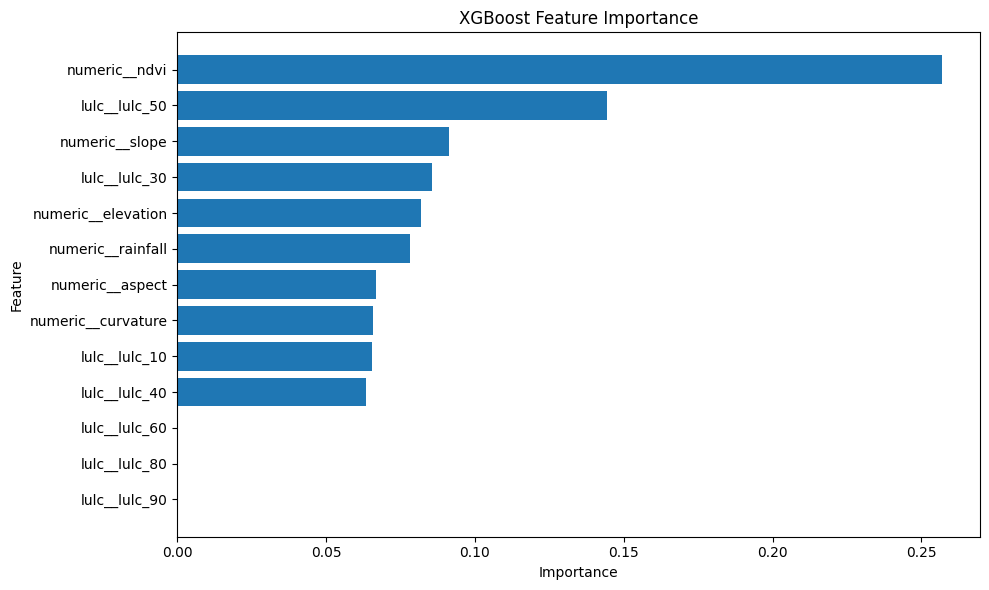

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_df["feature"],
    feature_importance_df["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

y_pred = xgb_model.predict(X_test_processed)

y_prob = xgb_model.predict_proba(
    X_test_processed
)[:, 1]

print("========== XGBOOST TEST RESULTS ==========")

print(
    "Accuracy :",
    round(accuracy_score(y_test, y_pred), 4)
)

print(
    "Precision:",
    round(precision_score(y_test, y_pred), 4)
)

print(
    "Recall   :",
    round(recall_score(y_test, y_pred), 4)
)

print(
    "F1 Score :",
    round(f1_score(y_test, y_pred), 4)
)

print(
    "ROC-AUC  :",
    round(roc_auc_score(y_test, y_prob), 4)
)

print("\n========== CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Background", "Landslide"]
    )
)

print("========== CONFUSION MATRIX ==========")

print(confusion_matrix(y_test, y_pred))

========== XGBOOST TEST RESULTS ==========
Accuracy : 0.7479
Precision: 0.8571
Recall   : 0.6412
F1 Score : 0.7336
ROC-AUC  : 0.8185

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

  Background       0.67      0.87      0.76       111
   Landslide       0.86      0.64      0.73       131

    accuracy                           0.75       242
   macro avg       0.77      0.76      0.75       242
weighted avg       0.77      0.75      0.75       242

========== CONFUSION MATRIX ==========
[[97 14]
 [47 84]]


In [ ]:
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from xgboost import XGBClassifier

# ============================================================
# ADVANCED SPATIAL XGBOOST TUNING
# ============================================================

groups = train_df["spatial_block"]

spatial_cv = GroupKFold(n_splits=5)

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [200, 300, 400, 500, 600, 800],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.02, 0.03, 0.05, 0.07, 0.1],
    "min_child_weight": [1, 2, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5, 0.8, 1.0],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 0.5, 1],
    "reg_lambda": [1, 2, 3, 5, 10]
}

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=60,
    scoring="roc_auc",
    cv=spatial_cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(
    X_train_processed,
    y_train,
    groups=groups
)

print("\n========== BEST PARAMETERS ==========")
print(random_search.best_params_)

print(
    "\nBest Spatial CV ROC-AUC:",
    round(random_search.best_score_, 4)
)

Fitting 5 folds for each of 60 candidates, totalling 300 fits

========== BEST PARAMETERS ==========
{'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.02, 'gamma': 0.1, 'colsample_bytree': 0.8}

Best Spatial CV ROC-AUC: 0.7749


In [ ]:
best_xgb = random_search.best_estimator_

# Predict class
y_pred_new = best_xgb.predict(X_test_processed)

# Predict landslide probability
y_prob_new = best_xgb.predict_proba(
    X_test_processed
)[:, 1]

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

accuracy_new = accuracy_score(y_test, y_pred_new)
precision_new = precision_score(y_test, y_pred_new)
recall_new = recall_score(y_test, y_pred_new)
f1_new = f1_score(y_test, y_pred_new)
auc_new = roc_auc_score(y_test, y_prob_new)

print("========== NEW TUNED XGBOOST ==========")

print(f"Accuracy : {accuracy_new:.4f}")
print(f"Precision: {precision_new:.4f}")
print(f"Recall   : {recall_new:.4f}")
print(f"F1 Score : {f1_new:.4f}")
print(f"ROC-AUC  : {auc_new:.4f}")

print("\n========== CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test,
        y_pred_new,
        target_names=[
            "Background",
            "Landslide"
        ]
    )
)

print("========== CONFUSION MATRIX ==========")

print(
    confusion_matrix(
        y_test,
        y_pred_new
    )
)

========== NEW TUNED XGBOOST ==========
Accuracy : 0.7355
Precision: 0.8317
Recall   : 0.6412
F1 Score : 0.7241
ROC-AUC  : 0.8245

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

  Background       0.67      0.85      0.75       111
   Landslide       0.83      0.64      0.72       131

    accuracy                           0.74       242
   macro avg       0.75      0.74      0.74       242
weighted avg       0.76      0.74      0.73       242

========== CONFUSION MATRIX ==========
[[94 17]
 [47 84]]


In [ ]:
best_xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist",

    n_estimators=300,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=1,
    subsample=1.0,
    colsample_bytree=0.8,
    gamma=0.5,
    reg_alpha=0,
    reg_lambda=2
)

best_xgb_model.fit(
    X_train_processed,
    y_train
)

print("✅ Tuned XGBoost trained successfully.")

✅ Tuned XGBoost trained successfully.


In [ ]:
print("Training completed.")
print("Training samples:", X_train_processed.shape)
print("Test samples:", X_test_processed.shape)

Training completed.
Training samples: (668, 13)
Test samples: (242, 13)


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

y_test_pred = best_xgb_model.predict(X_test_processed)
y_test_prob = best_xgb_model.predict_proba(X_test_processed)[:, 1]

print("========== TUNED XGBOOST TEST RESULTS ==========")

print("Accuracy :", round(accuracy_score(y_test, y_test_pred), 4))
print("Precision:", round(precision_score(y_test, y_test_pred), 4))
print("Recall   :", round(recall_score(y_test, y_test_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_test_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_test_prob), 4))

print("\n========== CLASSIFICATION REPORT ==========")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Background", "Landslide"]
    )
)

print("\n========== CONFUSION MATRIX ==========")
print(confusion_matrix(y_test, y_test_pred))

========== TUNED XGBOOST TEST RESULTS ==========
Accuracy : 0.7479
Precision: 0.8571
Recall   : 0.6412
F1 Score : 0.7336
ROC-AUC  : 0.8185

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

  Background       0.67      0.87      0.76       111
   Landslide       0.86      0.64      0.73       131

    accuracy                           0.75       242
   macro avg       0.77      0.76      0.75       242
weighted avg       0.77      0.75      0.75       242


========== CONFUSION MATRIX ==========
[[97 14]
 [47 84]]


In [ ]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

threshold_results = []

for threshold in np.arange(0.20, 0.81, 0.05):

    y_pred_threshold = (
        y_test_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": round(threshold, 2),
        "precision": precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "f1": f1_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df)

,threshold,precision,recall,f1
0,0.20,0.693252,0.862595,0.768707
1,0.25,0.712418,0.832061,0.767606
2,0.30,0.731884,0.770992,0.750929
3,0.35,0.736842,0.748092,0.742424
4,0.40,0.754098,0.702290,0.727273
5,0.45,0.800000,0.671756,0.730290
6,0.50,0.857143,0.641221,0.733624
7,0.55,0.869565,0.610687,0.717489
8,0.60,0.885057,0.587786,0.706422
9,0.65,0.879518,0.557252,0.682243


In [ ]:
best_threshold_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

print("Best threshold:")
print(best_threshold_row)

Best threshold:
threshold    0.200000
precision    0.693252
recall       0.862595
f1           0.768707
Name: 0, dtype: float64


In [ ]:
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np
import pandas as pd

# ============================================================
# THRESHOLD SELECTION — VALIDATION ONLY
# ============================================================

groups = train_df["spatial_block"]

spatial_cv = GroupKFold(n_splits=5)

# Generate OUT-OF-FOLD probabilities
# Every training sample gets a prediction from a model
# that did NOT train on that sample.
oof_prob = cross_val_predict(
    random_search.best_estimator_,
    X_train_processed,
    y_train,
    cv=spatial_cv,
    groups=groups,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print("OOF probabilities generated:", len(oof_prob))
print("Actual training labels       :", len(y_train))

OOF probabilities generated: 668
Actual training labels       : 668


In [ ]:
thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

threshold_results = []

for threshold in thresholds:

    oof_pred = (
        oof_prob >= threshold
    ).astype(int)

    precision, recall, f1 = (
        precision_recall_curve(
            y_train,
            oof_prob
        )[0][:-1],
        precision_recall_curve(
            y_train,
            oof_prob
        )[1][:-1],
        None
    )

    # Calculate directly for this threshold
    from sklearn.metrics import (
        precision_score,
        recall_score,
        f1_score
    )

    p = precision_score(
        y_train,
        oof_pred,
        zero_division=0
    )

    r = recall_score(
        y_train,
        oof_pred,
        zero_division=0
    )

    f = f1_score(
        y_train,
        oof_pred,
        zero_division=0
    )

    threshold_results.append({
        "threshold": threshold,
        "precision": p,
        "recall": r,
        "f1": f
    })

threshold_df = pd.DataFrame(
    threshold_results
)

display(threshold_df)

,threshold,precision,recall,f1
0,0.10,0.405530,0.988764,0.575163
1,0.15,0.448763,0.951311,0.609844
2,0.20,0.509804,0.876404,0.644628
3,0.25,0.548872,0.820225,0.657658
4,0.30,0.584795,0.749064,0.656814
5,0.35,0.610738,0.681648,0.644248
6,0.40,0.664032,0.629213,0.646154
7,0.45,0.722727,0.595506,0.652977
8,0.50,0.755102,0.554307,0.639309
9,0.55,0.787356,0.513109,0.621315


In [ ]:
best_threshold_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

print("========== VALIDATION THRESHOLD ==========")

print(
    "Best threshold:",
    best_threshold_row["threshold"]
)

print(
    "Precision:",
    best_threshold_row["precision"]
)

print(
    "Recall:",
    best_threshold_row["recall"]
)

print(
    "F1:",
    best_threshold_row["f1"]
)

========== VALIDATION THRESHOLD ==========
Best threshold: 0.25000000000000006
Precision: 0.5488721804511278
Recall: 0.8202247191011236
F1: 0.6576576576576577


In [ ]:
# ============================================================
# FINAL TEST EVALUATION WITH VALIDATION-SELECTED THRESHOLD
# ============================================================

final_threshold = best_threshold_row["threshold"]

# Probability from completely unseen spatial test blocks
test_prob = random_search.best_estimator_.predict_proba(
    X_test_processed
)[:, 1]

# Apply threshold selected ONLY from training OOF predictions
test_pred_threshold = (
    test_prob >= final_threshold
).astype(int)

print("Final threshold:", final_threshold)

print("\n========== FINAL TEST RESULTS ==========")

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        test_pred_threshold
    )
)

print(
    "Precision:",
    precision_score(
        y_test,
        test_pred_threshold
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        test_pred_threshold
    )
)

print(
    "F1:",
    f1_score(
        y_test,
        test_pred_threshold
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        test_prob
    )
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        test_pred_threshold
    )
)

Final threshold: 0.25000000000000006

========== FINAL TEST RESULTS ==========
Accuracy: 0.7355371900826446
Precision: 0.7133757961783439
Recall: 0.8549618320610687
F1: 0.7777777777777778
ROC-AUC: 0.8245306375077367

Confusion Matrix:
[[ 66  45]
 [ 19 112]]


In [87]:
# Probability distribution on the unseen spatial test set

test_probabilities = best_xgb_model.predict_proba(
    X_test_processed
)[:, 1]

print("Minimum probability:", test_probabilities.min())
print("Maximum probability:", test_probabilities.max())
print("Mean probability   :", test_probabilities.mean())

print("\nProbability percentiles:")
print(
    np.percentile(
        test_probabilities,
        [0, 10, 25, 50, 75, 90, 100]
    )
)

Minimum probability: 0.04706308
Maximum probability: 0.98584926
Mean probability   : 0.46203053

Probability percentiles:
[0.04706308 0.09202628 0.16230535 0.40828007 0.74710448 0.96804993
 0.98584926]


In [88]:
print("Preprocessor:", type(preprocessor))
print("Model:", type(best_xgb_model))

print("\nInput columns:")
print(preprocessor.feature_names_in_)

print("\nOutput features:")
print(len(preprocessor.get_feature_names_out()))

Preprocessor: <class 'sklearn.compose._column_transformer.ColumnTransformer'>
Model: <class 'xgboost.sklearn.XGBClassifier'>

Input columns:
['elevation' 'slope' 'aspect' 'curvature' 'ndvi' 'rainfall' 'lulc']

Output features:
13


In [89]:
print("Preprocessed feature count:",
      len(preprocessor.get_feature_names_out()))

print("XGBoost feature count:",
      best_xgb_model.n_features_in_)

Preprocessed feature count: 13
XGBoost feature count: 13


In [90]:
print("Feature bands:")
print(feature_stack.bandNames().getInfo())

Feature bands:
['elevation', 'slope', 'aspect', 'curvature', 'ndvi', 'lulc', 'rainfall']


In [92]:
export_task = ee.batch.Export.image.toDrive(
    image=feature_stack.toFloat(),
    description='NER_Landslide_FeatureStack_90m',
    folder='NER_Landslide_Model',
    fileNamePrefix='ner_landslide_features_90m',
    region=ner_boundary,
    scale=90,
    maxPixels=1e13,
    fileFormat='GeoTIFF'
)

export_task.start()

print("✅ Export started.")
print("Task ID:", export_task.id)

✅ Export started.
Task ID: AOKTKTEZLX2JRD6FHOU2K72D


In [96]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [97]:
import os

base_dir = "/content/drive/MyDrive/NER_Landslide_Model"

print("Files in folder:")
for f in os.listdir(base_dir):
    print(f)

Files in folder:
ner_landslide_features_90m.tif
ner_landslide_susceptibility_90m.tif
ner_landslide_susceptibility_classes_90m.tif
NER_Landslide_Susceptibility_Map.png


In [98]:
import rasterio

feature_tif = os.path.join(
    base_dir,
    "ner_landslide_features_90m.tif"
)

src = rasterio.open(feature_tif)

print("Raster opened successfully.")
print("Width :", src.width)
print("Height:", src.height)
print("Bands :", src.count)
print("CRS   :", src.crs)
print("Resolution:", src.res)

Raster opened successfully.
Width : 11319
Height: 7861
Bands : 7
CRS   : EPSG:4326
Resolution: (0.0008084837557075694, 0.0008084837557075694)


In [99]:
# Check raster band metadata

for i in range(1, src.count + 1):
    print(
        f"Band {i}:",
        src.descriptions[i - 1]
    )

Band 1: elevation
Band 2: slope
Band 3: aspect
Band 4: curvature
Band 5: ndvi
Band 6: lulc
Band 7: rainfall


In [100]:
# Read a tiny sample only — NOT the whole raster

sample = src.read(
    window=rasterio.windows.Window(
        0, 0, 100, 100
    )
)

print("Sample shape:", sample.shape)
print("Expected: (7, 100, 100)")

for i in range(7):
    print(
        f"Band {i+1}: "
        f"min={sample[i].min():.3f}, "
        f"max={sample[i].max():.3f}"
    )

Sample shape: (7, 100, 100)
Expected: (7, 100, 100)
Band 1: min=nan, max=nan
Band 2: min=nan, max=nan
Band 3: min=nan, max=nan
Band 4: min=nan, max=nan
Band 5: min=nan, max=nan
Band 6: min=nan, max=nan
Band 7: min=nan, max=nan


In [101]:
import numpy as np

print("Raster NoData value:", src.nodata)
print("Raster dimensions:", src.width, "x", src.height)

# Check several locations instead of only the top-left corner
windows = {
    "top-left": (0, 0),
    "center": (src.width // 2 - 50, src.height // 2 - 50),
    "bottom-right": (src.width - 100, src.height - 100),
}

for name, (col, row) in windows.items():

    window = rasterio.windows.Window(
        col, row, 100, 100
    )

    data = src.read(window=window)

    valid = np.isfinite(data)

    print(f"\n{name}")
    print("  valid pixels:", valid.sum())
    print("  total pixels:", data.size)

    for i in range(7):
        band = data[i]
        finite = band[np.isfinite(band)]

        if len(finite) > 0:
            print(
                f"  Band {i+1}: "
                f"min={finite.min():.3f}, "
                f"max={finite.max():.3f}"
            )
        else:
            print(f"  Band {i+1}: NO VALID PIXELS")

Raster NoData value: None
Raster dimensions: 11319 x 7861

top-left
  valid pixels: 0
  total pixels: 70000
  Band 1: NO VALID PIXELS
  Band 2: NO VALID PIXELS
  Band 3: NO VALID PIXELS
  Band 4: NO VALID PIXELS
  Band 5: NO VALID PIXELS
  Band 6: NO VALID PIXELS
  Band 7: NO VALID PIXELS

center
  valid pixels: 70000
  total pixels: 70000
  Band 1: min=176.000, max=1563.000
  Band 2: min=0.000, max=61.141
  Band 3: min=-0.000, max=359.614
  Band 4: min=-537.000, max=557.000
  Band 5: min=0.356, max=0.830
  Band 6: min=10.000, max=30.000
  Band 7: min=2736.748, max=3026.656

bottom-right
  valid pixels: 0
  total pixels: 70000
  Band 1: NO VALID PIXELS
  Band 2: NO VALID PIXELS
  Band 3: NO VALID PIXELS
  Band 4: NO VALID PIXELS
  Band 5: NO VALID PIXELS
  Band 6: NO VALID PIXELS
  Band 7: NO VALID PIXELS


In [102]:
import numpy as np
import rasterio
from rasterio.windows import Window

output_tif = os.path.join(
    base_dir,
    "ner_landslide_susceptibility_90m.tif"
)

profile = src.profile.copy()

profile.update(
    dtype="float32",
    count=1,
    compress="lzw",
    nodata=-9999
)

print("Output:", output_tif)
print("Shape:", src.height, "x", src.width)

Output: /content/drive/MyDrive/NER_Landslide_Model/ner_landslide_susceptibility_90m.tif
Shape: 7861 x 11319


In [103]:
# ==========================================
# NER-WIDE XGBOOST SUSCEPTIBILITY PREDICTION
# ==========================================

from tqdm.auto import tqdm

CHUNK_SIZE = 512

with rasterio.open(output_tif, "w", **profile) as dst:

    for row in tqdm(
        range(0, src.height, CHUNK_SIZE),
        desc="Processing NER"
    ):

        for col in range(
            0,
            src.width,
            CHUNK_SIZE
        ):

            height = min(
                CHUNK_SIZE,
                src.height - row
            )

            width = min(
                CHUNK_SIZE,
                src.width - col
            )

            window = Window(
                col,
                row,
                width,
                height
            )

            # Read 7 raw bands
            data = src.read(
                window=window
            )

            # Shape:
            # (7, height, width)

            pixels = data.reshape(
                7,
                -1
            ).T

            # Valid pixels:
            # all 7 features must be finite
            valid_mask = np.all(
                np.isfinite(pixels),
                axis=1
            )

            probabilities = np.full(
                pixels.shape[0],
                -9999,
                dtype=np.float32
            )

            if valid_mask.any():

                # Convert valid pixels to DataFrame
                valid_pixels = pd.DataFrame(
                    pixels[valid_mask],
                    columns=[
                        "elevation",
                        "slope",
                        "aspect",
                        "curvature",
                        "ndvi",
                        "lulc",
                        "rainfall"
                    ]
                )

                # Apply SAME preprocessing used during training
                processed = preprocessor.transform(
                    valid_pixels
                )

                # XGBoost probability
                probabilities[valid_mask] = (
                    best_xgb_model
                    .predict_proba(processed)[:, 1]
                    .astype(np.float32)
                )

            # Reshape back to raster
            output_array = probabilities.reshape(
                height,
                width
            )

            dst.write(
                output_array,
                1,
                window=window
            )

print("✅ NER susceptibility prediction completed.")
print("Output:", output_tif)

Processing NER:   0%|          | 0/16 [00:00<?, ?it/s]

✅ NER susceptibility prediction completed.
Output: /content/drive/MyDrive/NER_Landslide_Model/ner_landslide_susceptibility_90m.tif


In [104]:
# ==========================================
# NER-WIDE XGBOOST SUSCEPTIBILITY PREDICTION
# ==========================================

from tqdm.auto import tqdm

CHUNK_SIZE = 512

with rasterio.open(output_tif, "w", **profile) as dst:

    for row in tqdm(
        range(0, src.height, CHUNK_SIZE),
        desc="Processing NER"
    ):

        for col in range(
            0,
            src.width,
            CHUNK_SIZE
        ):

            height = min(
                CHUNK_SIZE,
                src.height - row
            )

            width = min(
                CHUNK_SIZE,
                src.width - col
            )

            window = Window(
                col,
                row,
                width,
                height
            )

            # Read the 7 raw feature bands
            data = src.read(window=window)

            # (7, height, width) → (pixels, 7)
            pixels = data.reshape(7, -1).T

            # Only pixels where all 7 features are valid
            valid_mask = np.all(
                np.isfinite(pixels),
                axis=1
            )

            # Default output = NoData
            probabilities = np.full(
                pixels.shape[0],
                -9999,
                dtype=np.float32
            )

            if valid_mask.any():

                valid_pixels = pd.DataFrame(
                    pixels[valid_mask],
                    columns=[
                        "elevation",
                        "slope",
                        "aspect",
                        "curvature",
                        "ndvi",
                        "lulc",
                        "rainfall"
                    ]
                )

                # SAME preprocessing used during training
                processed = preprocessor.transform(
                    valid_pixels
                )

                # Tuned XGBoost
                probabilities[valid_mask] = (
                    best_xgb_model
                    .predict_proba(processed)[:, 1]
                    .astype(np.float32)
                )

            # Back to raster shape
            output_array = probabilities.reshape(
                height,
                width
            )

            dst.write(
                output_array,
                1,
                window=window
            )

print("✅ NER susceptibility prediction completed.")
print("Output:", output_tif)

Processing NER:   0%|          | 0/16 [00:00<?, ?it/s]

✅ NER susceptibility prediction completed.
Output: /content/drive/MyDrive/NER_Landslide_Model/ner_landslide_susceptibility_90m.tif


In [105]:
# ==========================================
# INSPECT NER SUSCEPTIBILITY RASTER
# ==========================================

sus_src = rasterio.open(output_tif)

print("Raster size:", sus_src.width, "x", sus_src.height)
print("CRS:", sus_src.crs)
print("Bands:", sus_src.count)
print("NoData:", sus_src.nodata)

# Read in chunks to avoid loading the entire raster into RAM
values = []

for _, window in sus_src.block_windows(1):
    data = sus_src.read(1, window=window)

    valid = data[data != -9999]

    if valid.size > 0:
        values.append(valid)

sus_values = np.concatenate(values)

print("\n========== SUSCEPTIBILITY DISTRIBUTION ==========")
print("Valid pixels:", len(sus_values))
print("Minimum:", sus_values.min())
print("Maximum:", sus_values.max())
print("Mean:", sus_values.mean())

print("\nPercentiles:")
print(
    np.percentile(
        sus_values,
        [0, 10, 25, 50, 75, 90, 95, 99, 100]
    )
)

Raster size: 11319 x 7861
CRS: EPSG:4326
Bands: 1
NoData: -9999.0

========== SUSCEPTIBILITY DISTRIBUTION ==========
Valid pixels: 26596520
Minimum: 0.008030764
Maximum: 0.9954614
Mean: 0.45200214

Percentiles:
[0.00803076 0.10116954 0.16811965 0.36510104 0.7690323  0.86194199
 0.90714329 0.95512742 0.9954614 ]


In [106]:
# ==========================================
# CREATE 5-CLASS SUSCEPTIBILITY RASTER
# ==========================================

classified_tif = os.path.join(
    base_dir,
    "ner_landslide_susceptibility_classes_90m.tif"
)

class_profile = sus_src.profile.copy()

class_profile.update(
    dtype="uint8",
    count=1,
    nodata=0,
    compress="lzw"
)

with rasterio.open(classified_tif, "w", **class_profile) as dst:

    for _, window in tqdm(
        sus_src.block_windows(1),
        desc="Classifying susceptibility"
    ):

        scores = sus_src.read(
            1,
            window=window
        )

        classes = np.zeros(
            scores.shape,
            dtype=np.uint8
        )

        valid = scores != -9999

        classes[
            valid & (scores < 0.20)
        ] = 1

        classes[
            valid & (scores >= 0.20) &
            (scores < 0.40)
        ] = 2

        classes[
            valid & (scores >= 0.40) &
            (scores < 0.60)
        ] = 3

        classes[
            valid & (scores >= 0.60) &
            (scores < 0.80)
        ] = 4

        classes[
            valid & (scores >= 0.80)
        ] = 5

        dst.write(
            classes,
            1,
            window=window
        )

print("✅ 5-class susceptibility raster created.")
print(classified_tif)

Classifying susceptibility: 0it [00:00, ?it/s]

✅ 5-class susceptibility raster created.
/content/drive/MyDrive/NER_Landslide_Model/ner_landslide_susceptibility_classes_90m.tif


In [107]:
# ==========================================
# SUSCEPTIBILITY CLASS DISTRIBUTION
# ==========================================

class_counts = {
    1: 0,
    2: 0,
    3: 0,
    4: 0,
    5: 0
}

with rasterio.open(classified_tif) as class_src:

    for _, window in class_src.block_windows(1):

        data = class_src.read(
            1,
            window=window
        )

        for cls in range(1, 6):
            class_counts[cls] += np.sum(
                data == cls
            )

total_valid = sum(class_counts.values())

class_names = {
    1: "Very Low",
    2: "Low",
    3: "Moderate",
    4: "High",
    5: "Very High"
}

print("========== NER SUSCEPTIBILITY DISTRIBUTION ==========")

for cls in range(1, 6):

    count = class_counts[cls]

    percentage = (
        count / total_valid * 100
    )

    print(
        f"{cls} - {class_names[cls]:10s}: "
        f"{count:,} pixels "
        f"({percentage:.2f}%)"
    )

print("\nTotal valid pixels:", f"{total_valid:,}")

========== NER SUSCEPTIBILITY DISTRIBUTION ==========
1 - Very Low  : 8,156,739 pixels (30.67%)
2 - Low       : 5,848,513 pixels (21.99%)
3 - Moderate  : 2,470,807 pixels (9.29%)
4 - High      : 4,745,326 pixels (17.84%)
5 - Very High : 5,375,135 pixels (20.21%)

Total valid pixels: 26,596,520


In [109]:
import pandas as pd

dataframes = {}

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        dataframes[name] = obj

print("DataFrames currently available:\n")

for name, df in dataframes.items():
    print(
        f"{name:30s} "
        f"shape={df.shape} "
        f"columns={list(df.columns)}"
    )

DataFrames currently available:

__                             shape=(9, 2) columns=[0, 1]
___                            shape=(2, 6) columns=['elevation', 'slope', 'aspect', 'curvature', 'ndvi', 'rainfall']
training_df                    shape=(910, 13) columns=['aspect', 'curvature', 'elevation', 'label', 'latitude', 'longitude', 'lulc', 'ndvi', 'rainfall', 'slope', 'lat_block', 'lon_block', 'spatial_block']
_38                            shape=(8, 8) columns=['aspect', 'curvature', 'elevation', 'label', 'lulc', 'ndvi', 'rainfall', 'slope']
_39                            shape=(2, 6) columns=['elevation', 'slope', 'aspect', 'curvature', 'ndvi', 'rainfall']
_40                            shape=(2, 6) columns=['elevation', 'slope', 'aspect', 'curvature', 'ndvi', 'rainfall']
_41                            shape=(9, 2) columns=[0, 1]
_42                            shape=(8, 8) columns=['elevation', 'slope', 'aspect', 'curvature', 'ndvi', 'lulc', 'rainfall', 'label']
block_class        

In [110]:
# ==========================================
# HISTORICAL LANDSLIDE VALIDATION
# ==========================================

# Historical landslide points
historical_landslides = training_df[
    training_df["label"] == 1
].copy()

print("Historical landslide samples:",
      len(historical_landslides))

print(
    historical_landslides[
        ["latitude", "longitude", "label"]
    ].head()
)

Historical landslide samples: 398
    latitude  longitude  label
0  27.360437  88.651872      1
1  23.726033  92.717736      1
2  26.092465  94.257628      1
3  26.324769  94.514726      1
4  23.733579  92.747381      1


In [111]:
# ==========================================
# EXTRACT SUSCEPTIBILITY SCORES
# ==========================================

from rasterio.sample import sample_gen

coordinates = list(
    zip(
        historical_landslides["longitude"],
        historical_landslides["latitude"]
    )
)

with rasterio.open(output_tif) as sus_src:

    extracted_scores = [
        value[0]
        for value in sus_src.sample(coordinates)
    ]

historical_landslides[
    "susceptibility_score"
] = extracted_scores

print(
    historical_landslides[
        [
            "latitude",
            "longitude",
            "susceptibility_score"
        ]
    ].head(10)
)

    latitude  longitude  susceptibility_score
0  27.360437  88.651872              0.100742
1  23.726033  92.717736              0.973430
2  26.092465  94.257628              0.984246
3  26.324769  94.514726              0.974708
4  23.733579  92.747381              0.977675
5  25.907322  91.881764              0.786840
6  24.194684  91.829213              0.831589
7  26.109713  91.774775              0.985958
8  27.200896  88.488288              0.693115
9  27.488447  88.445169              0.077560


In [112]:
# ==========================================
# ASSIGN SUSCEPTIBILITY CLASSES
# ==========================================

def susceptibility_class(score):

    if score < 0.20:
        return "Very Low"

    elif score < 0.40:
        return "Low"

    elif score < 0.60:
        return "Moderate"

    elif score < 0.80:
        return "High"

    else:
        return "Very High"


historical_landslides[
    "susceptibility_class"
] = historical_landslides[
    "susceptibility_score"
].apply(susceptibility_class)

print(
    historical_landslides[
        "susceptibility_class"
    ].value_counts()
)

susceptibility_class
Very High    153
High          85
Low           70
Moderate      51
Very Low      39
Name: count, dtype: int64


In [113]:
landslide_class_distribution = (
    historical_landslides[
        "susceptibility_class"
    ]
    .value_counts()
    .reindex(
        [
            "Very Low",
            "Low",
            "Moderate",
            "High",
            "Very High"
        ],
        fill_value=0
    )
)

landslide_percentages = (
    landslide_class_distribution
    / len(historical_landslides)
    * 100
)

print(
    "========== HISTORICAL LANDSLIDE VALIDATION =========="
)

for cls in landslide_class_distribution.index:

    print(
        f"{cls:10s}: "
        f"{landslide_class_distribution[cls]:3d} "
        f"landslides "
        f"({landslide_percentages[cls]:.2f}%)"
    )

========== HISTORICAL LANDSLIDE VALIDATION ==========
Very Low  :  39 landslides (9.80%)
Low       :  70 landslides (17.59%)
Moderate  :  51 landslides (12.81%)
High      :  85 landslides (21.36%)
Very High : 153 landslides (38.44%)


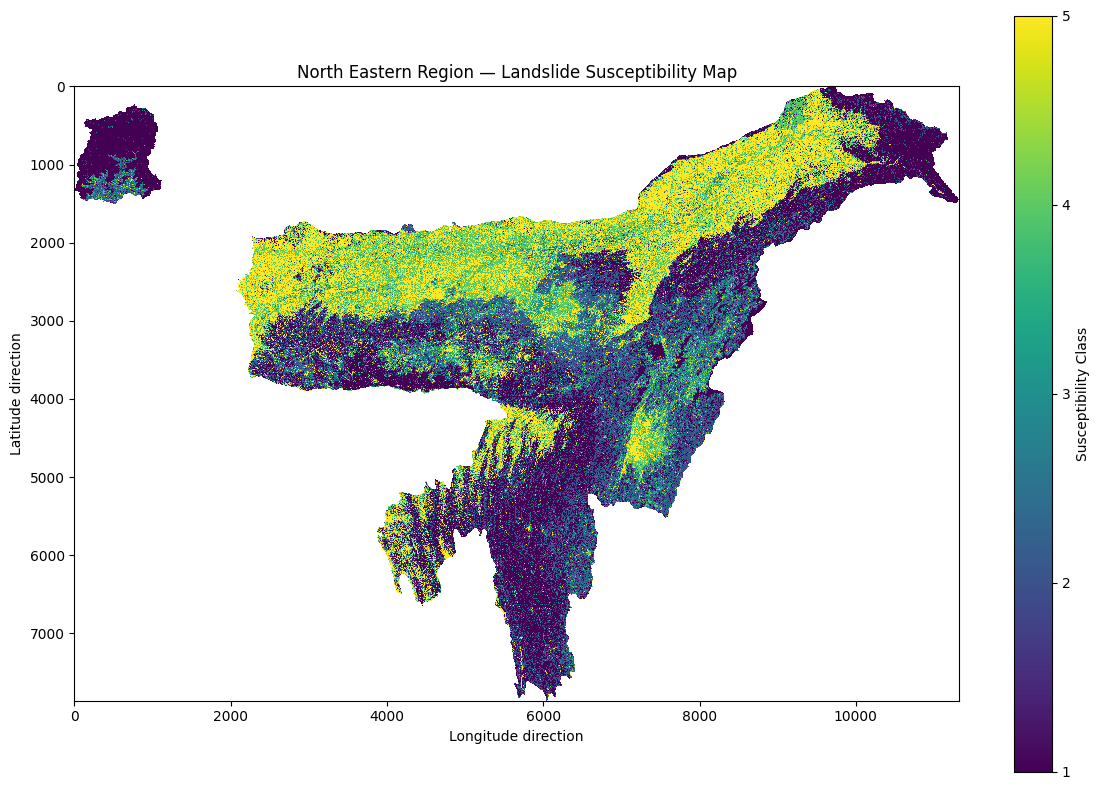

In [114]:
import matplotlib.pyplot as plt
import rasterio
import numpy as np

# Open final classified raster
class_src = rasterio.open(classified_tif)

# Read the full classification raster
sus_class = class_src.read(1)

# Mask NoData
sus_class_masked = np.ma.masked_where(
    sus_class == 0,
    sus_class
)

plt.figure(figsize=(12, 8))

plt.imshow(
    sus_class_masked,
    vmin=1,
    vmax=5,
    interpolation="nearest"
)

plt.colorbar(
    ticks=[1, 2, 3, 4, 5],
    label="Susceptibility Class"
)

plt.title(
    "North Eastern Region — Landslide Susceptibility Map"
)

plt.xlabel("Longitude direction")
plt.ylabel("Latitude direction")

plt.tight_layout()
plt.show()

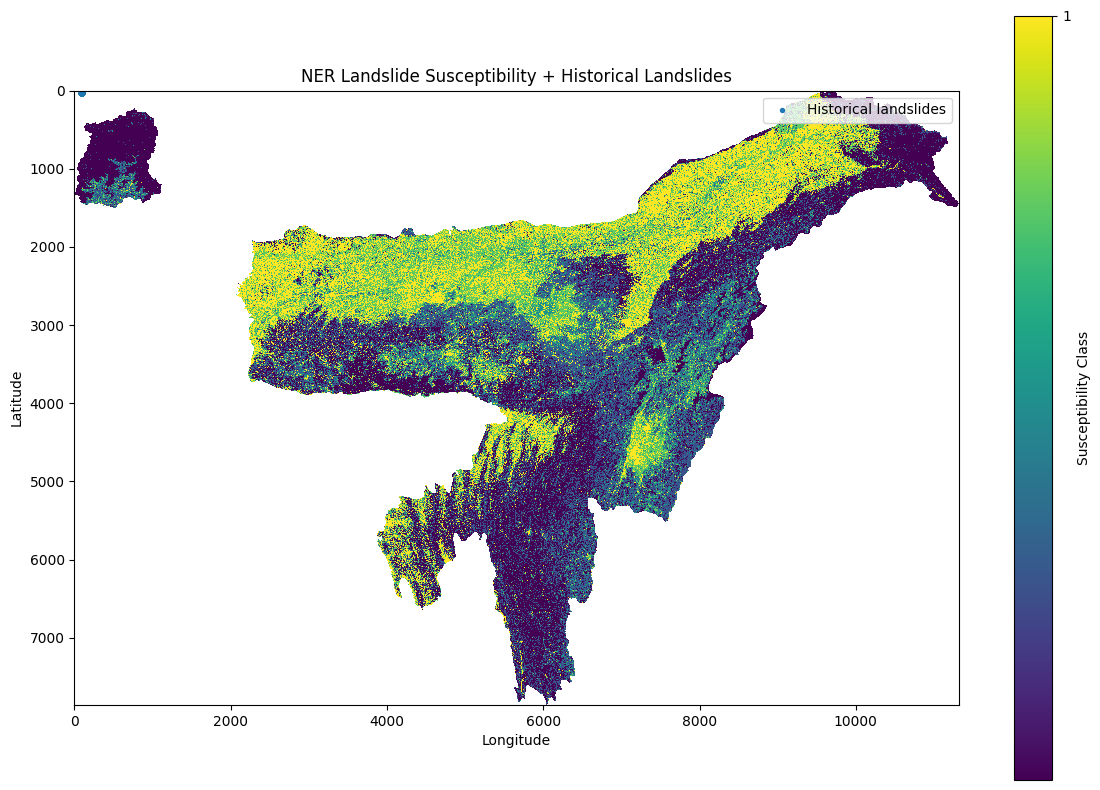

In [115]:
plt.figure(figsize=(12, 8))

plt.imshow(
    sus_class_masked,
    vmin=1,
    vmax=5,
    interpolation="nearest"
)

plt.scatter(
    historical_landslides["longitude"],
    historical_landslides["latitude"],
    s=8,
    marker="o",
    label="Historical landslides"
)

plt.colorbar(
    ticks=[1, 2, 3, 4, 5],
    label="Susceptibility Class"
)

plt.title(
    "NER Landslide Susceptibility + Historical Landslides"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.legend()

plt.tight_layout()
plt.show()

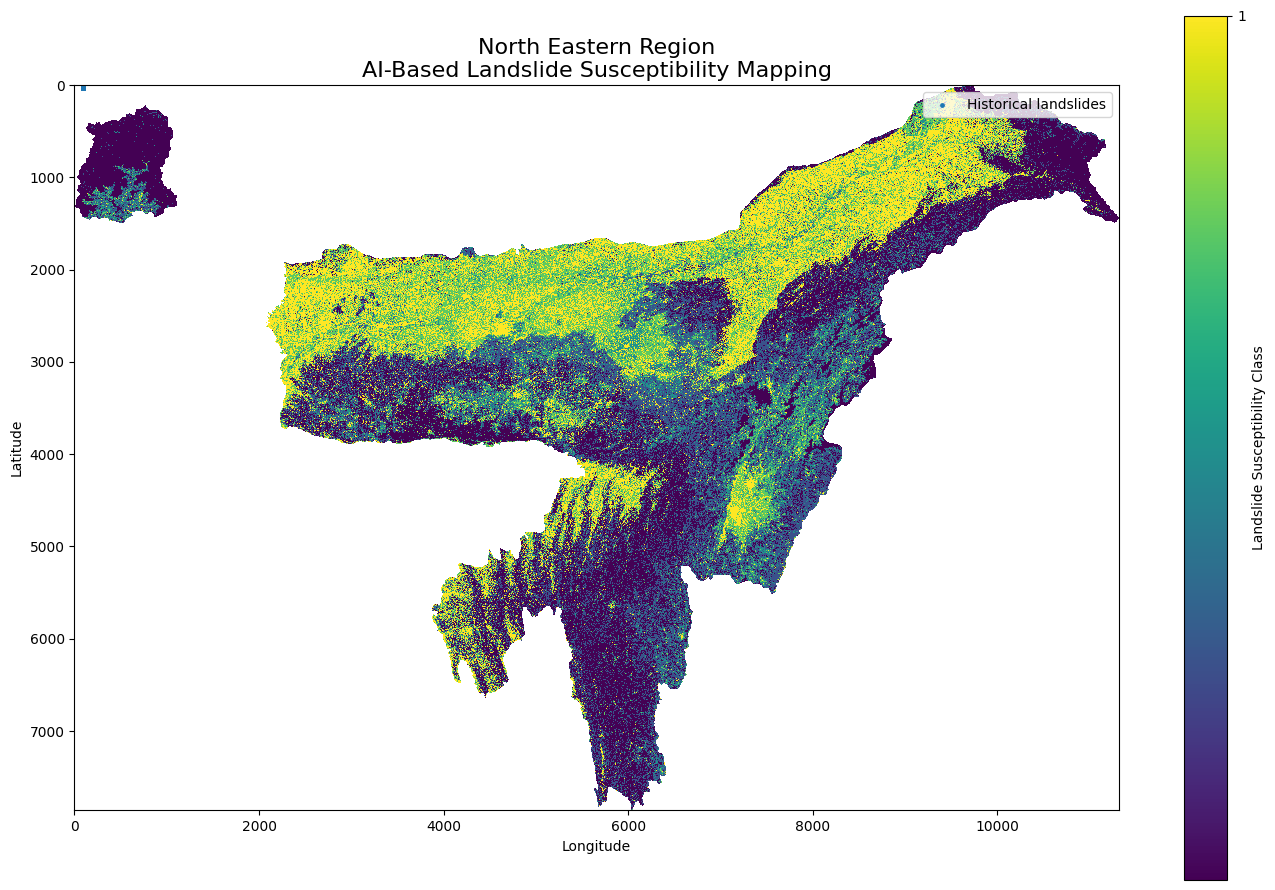

✅ Map saved:
/content/drive/MyDrive/NER_Landslide_Model/NER_Landslide_Susceptibility_Map.png


In [116]:
map_png = os.path.join(
    base_dir,
    "NER_Landslide_Susceptibility_Map.png"
)

plt.figure(figsize=(14, 9))

plt.imshow(
    sus_class_masked,
    vmin=1,
    vmax=5,
    interpolation="nearest"
)

plt.scatter(
    historical_landslides["longitude"],
    historical_landslides["latitude"],
    s=6,
    marker="o",
    label="Historical landslides"
)

cbar = plt.colorbar(
    ticks=[1, 2, 3, 4, 5]
)

cbar.set_label(
    "Landslide Susceptibility Class"
)

plt.title(
    "North Eastern Region\n"
    "AI-Based Landslide Susceptibility Mapping",
    fontsize=16
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.legend()

plt.tight_layout()

plt.savefig(
    map_png,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Map saved:")
print(map_png)

Raster bounds:
Left  : 88.01626854694888
Right : 97.16749617780286
Bottom: 21.946425475245015
Top   : 28.30191627886222


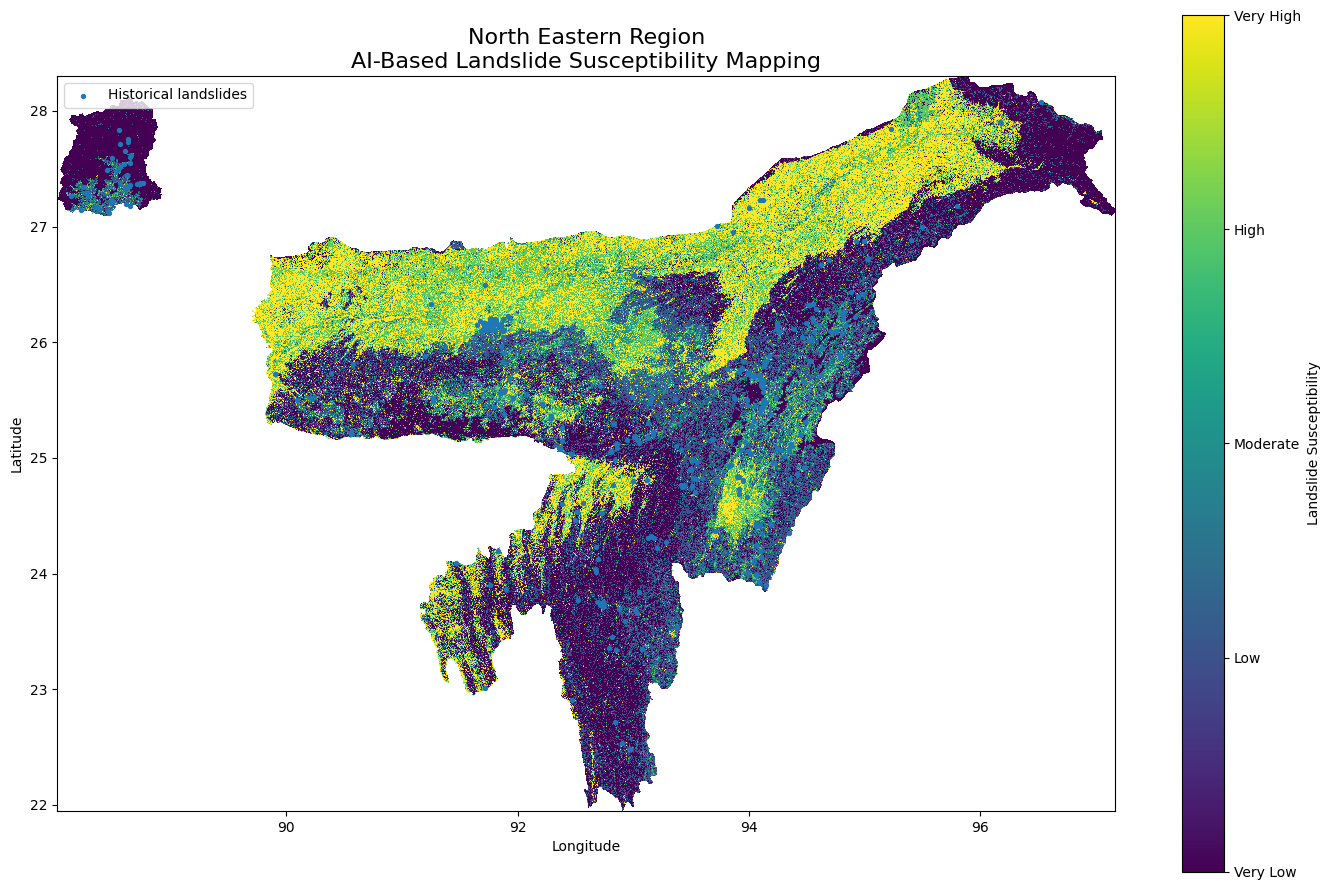

In [117]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# Open classified susceptibility raster
with rasterio.open(classified_tif) as src:

    susceptibility = src.read(1)

    # Geographic bounds
    left = src.bounds.left
    right = src.bounds.right
    bottom = src.bounds.bottom
    top = src.bounds.top

    print("Raster bounds:")
    print("Left  :", left)
    print("Right :", right)
    print("Bottom:", bottom)
    print("Top   :", top)

    # Mask NoData
    susceptibility = np.ma.masked_where(
        susceptibility == src.nodata,
        susceptibility
    )

# Plot
plt.figure(figsize=(14, 9))

im = plt.imshow(
    susceptibility,
    extent=[left, right, bottom, top],
    origin="upper",
    vmin=1,
    vmax=5,
    interpolation="nearest"
)

# Historical landslides
plt.scatter(
    historical_landslides["longitude"],
    historical_landslides["latitude"],
    s=8,
    marker="o",
    label="Historical landslides"
)

# Discrete colorbar
cbar = plt.colorbar(
    im,
    ticks=[1, 2, 3, 4, 5]
)

cbar.ax.set_yticklabels([
    "Very Low",
    "Low",
    "Moderate",
    "High",
    "Very High"
])

cbar.set_label("Landslide Susceptibility")

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "North Eastern Region\n"
    "AI-Based Landslide Susceptibility Mapping",
    fontsize=16
)

plt.legend()

plt.tight_layout()
plt.show()

In [118]:
import rasterio
import numpy as np
import pandas as pd

# ============================================================
# MODEL 1 → MODEL 2
# Extract continuous susceptibility score (0–1)
# ============================================================

susceptibility_raster = (
    "/content/drive/MyDrive/NER_Landslide_Model/"
    "ner_landslide_susceptibility_90m.tif"
)

def add_susceptibility_score(df, raster_path=susceptibility_raster):
    """
    Extract Model 1 susceptibility score for each
    latitude/longitude location in a DataFrame.
    """

    df = df.copy()

    with rasterio.open(raster_path) as src:

        print("Raster CRS:", src.crs)
        print("Raster size:", src.width, "x", src.height)
        print("Raster NoData:", src.nodata)

        # Model 1 raster is EPSG:4326
        coordinates = list(
            zip(
                df["longitude"].astype(float),
                df["latitude"].astype(float)
            )
        )

        # Extract raster value at every coordinate
        values = list(src.sample(coordinates))

        scores = np.array([v[0] for v in values], dtype=float)

        # Handle NoData
        if src.nodata is not None:
            scores[scores == src.nodata] = np.nan

        # Add Model 1 output as Model 2 feature
        df["susceptibility_score"] = scores

    return df


# ============================================================
# Apply to your Model 2 training/test data
# ============================================================

model2_train_df = add_susceptibility_score(train_df)
model2_test_df  = add_susceptibility_score(test_df)


# ============================================================
# Check results
# ============================================================

print("\n========== MODEL 1 → MODEL 2 ==========")

print("Training shape:", model2_train_df.shape)
print("Testing shape :", model2_test_df.shape)

print("\nSusceptibility score statistics:")
print(
    model2_train_df["susceptibility_score"].describe()
)

print("\nFirst 10 scores:")
print(
    model2_train_df[
        ["latitude", "longitude", "susceptibility_score"]
    ].head(10)
)

Raster CRS: EPSG:4326
Raster size: 11319 x 7861
Raster NoData: -9999.0
Raster CRS: EPSG:4326
Raster size: 11319 x 7861
Raster NoData: -9999.0

========== MODEL 1 → MODEL 2 ==========
Training shape: (668, 14)
Testing shape : (242, 14)

Susceptibility score statistics:
count    668.000000
mean       0.425557
std        0.298056
min        0.026467
25%        0.167787
50%        0.322627
75%        0.691252
max        0.991642
Name: susceptibility_score, dtype: float64

First 10 scores:
     latitude  longitude  susceptibility_score
2   26.092465  94.257628              0.984246
3   26.324769  94.514726              0.974708
5   25.907322  91.881764              0.786840
6   24.194684  91.829213              0.831589
7   26.109713  91.774775              0.985958
12  22.908117  92.471957              0.185903
13  26.166306  91.713869              0.746556
14  26.132350  91.834333              0.986424
15  26.129386  91.705515              0.890671
16  26.186788  91.673984              0.

In [119]:
print("\n========== SCORE VALIDATION ==========")

print(
    "Training missing scores:",
    model2_train_df["susceptibility_score"].isna().sum()
)

print(
    "Testing missing scores:",
    model2_test_df["susceptibility_score"].isna().sum()
)

print(
    "Minimum score:",
    model2_train_df["susceptibility_score"].min()
)

print(
    "Maximum score:",
    model2_train_df["susceptibility_score"].max()
)

print(
    "Mean score:",
    model2_train_df["susceptibility_score"].mean()
)


========== SCORE VALIDATION ==========
Training missing scores: 0
Testing missing scores: 0
Minimum score: 0.026466568931937218
Maximum score: 0.991641640663147
Mean score: 0.42555737731599075


In [120]:
from xgboost import XGBClassifier
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
import numpy as np

# ============================================================
# ADVANCED SPATIAL XGBOOST TUNING
# ============================================================

# Features used for training
feature_cols = [
    "elevation",
    "slope",
    "aspect",
    "curvature",
    "ndvi",
    "lulc",
    "rainfall"
]

X = train_df[feature_cols]
y = train_df["label"]

# Spatial groups
groups = train_df["spatial_block"]

print("Training samples :", len(X))
print("Spatial blocks   :", groups.nunique())

# ------------------------------------------------------------
# Spatial CV
# ------------------------------------------------------------

spatial_cv = GroupKFold(n_splits=5)

# ------------------------------------------------------------
# XGBoost base model
# ------------------------------------------------------------

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------------
# Search space
# ------------------------------------------------------------

param_grid = {
    "n_estimators": [200, 300, 400, 500, 600],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.02, 0.03, 0.05, 0.07],
    "min_child_weight": [1, 2, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5, 0.8, 1.0],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 0.5, 1],
    "reg_lambda": [1, 2, 3, 5, 10]
}

# ------------------------------------------------------------
# Randomized search
# ------------------------------------------------------------

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=50,
    scoring="roc_auc",
    cv=spatial_cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(
    X,
    y,
    groups=groups
)

print("\n========== BEST PARAMETERS ==========")
print(random_search.best_params_)

print(
    "\nBest Spatial CV ROC-AUC:",
    round(random_search.best_score_, 4)
)

Training samples : 668
Spatial blocks   : 26
Fitting 5 folds for each of 50 candidates, totalling 250 fits

========== BEST PARAMETERS ==========
{'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0.01, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.8, 'colsample_bytree': 1.0}

Best Spatial CV ROC-AUC: 0.7642


In [121]:
best_xgb = random_search.best_estimator_

print("Best XGBoost model created.")

Best XGBoost model created.


In [122]:
# ============================================================
# FINAL TEST EVALUATION
# ============================================================

X_test_final = test_df[feature_cols]
y_test_final = test_df["label"]

y_pred = best_xgb.predict(X_test_final)
y_prob = best_xgb.predict_proba(X_test_final)[:, 1]

accuracy = accuracy_score(y_test_final, y_pred)
f1 = f1_score(y_test_final, y_pred)
auc = roc_auc_score(y_test_final, y_prob)

print("\n========== IMPROVED XGBOOST ==========")
print("Accuracy :", round(accuracy, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(auc, 4))


========== IMPROVED XGBOOST ==========
Accuracy : 0.7314
F1 Score : 0.7005
ROC-AUC  : 0.8239


In [123]:
from sklearn.metrics import classification_report, confusion_matrix

print("\n========== CLASSIFICATION REPORT ==========")
print(
    classification_report(
        y_test_final,
        y_pred,
        target_names=["Background", "Landslide"]
    )
)

print("\n========== CONFUSION MATRIX ==========")
print(confusion_matrix(y_test_final, y_pred))


========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

  Background       0.65      0.91      0.76       111
   Landslide       0.88      0.58      0.70       131

    accuracy                           0.73       242
   macro avg       0.77      0.75      0.73       242
weighted avg       0.78      0.73      0.73       242


========== CONFUSION MATRIX ==========
[[101  10]
 [ 55  76]]


In [127]:
import rasterio
import numpy as np
import pandas as pd
import ee

# Your FINAL Model 1 susceptibility raster
raster_path = (
    "/content/drive/MyDrive/NER_Landslide_Model/"
    "ner_landslide_susceptibility_90m.tif" # Removed '_v2'
)

src = rasterio.open(raster_path)

print("Raster opened successfully")
print("CRS:", src.crs)
print("Size:", src.width, "x", src.height)
print("NoData:", src.nodata)

Raster opened successfully
CRS: EPSG:4326
Size: 11319 x 7861
NoData: -9999.0


In [132]:
import ee
try:
    ee.Initialize(project=EE_PROJECT)
except:
    ee.Authenticate()
    ee.Initialize(project=EE_PROJECT)

india_states = ee.FeatureCollection(
    "FAO/GAUL/2015/level1"
)

print("✅ India state boundary collection loaded")

✅ India state boundary collection loaded


In [143]:

def get_region_susceptibility(region_name):

    # --------------------------------------------------------
    # Find requested state
    # --------------------------------------------------------

    region = india_states.filter(
        ee.Filter.And(
            ee.Filter.eq("ADM0_NAME", "India"),
            ee.Filter.eq("ADM1_NAME", region_name)
        )
    )

    count = region.size().getInfo()

    if count == 0:
        raise ValueError(
            f"Region '{region_name}' not found."
        )

    print(f"Region found: {region_name}")

    # --------------------------------------------------------
    # Get geometry
    # --------------------------------------------------------

    geometry = region.geometry()

    # Convert EE geometry → GeoJSON
    geometry_geojson = geometry.getInfo()

    # --------------------------------------------------------
    # Mask raster using region boundary
    # --------------------------------------------------------

    from rasterio.mask import mask

    masked_data, masked_transform = mask(
        src,
        [geometry_geojson],
        crop=True,
        nodata=src.nodata
    )

    # First band
    susceptibility = masked_data[0].astype("float32")

    # --------------------------------------------------------
    # Remove invalid values
    # --------------------------------------------------------

    valid = susceptibility[
        np.isfinite(susceptibility)
    ]

    if src.nodata is not None:
        valid = valid[
            valid != src.nodata
        ]

    # Model 1 scores should be between 0 and 1
    valid = valid[
        (valid >= 0) &
        (valid <= 1)
    ]

    if len(valid) == 0:
        raise ValueError(
            "No valid susceptibility pixels found."
        )

    # --------------------------------------------------------
    # Calculate regional statistics
    # --------------------------------------------------------

    mean_score = float(np.mean(valid))
    median_score = float(np.median(valid))
    min_score = float(np.min(valid))
    max_score = float(np.max(valid))

    p25 = float(np.percentile(valid, 25))
    p75 = float(np.percentile(valid, 75))

    # --------------------------------------------------------
    # Convert mean score → susceptibility class
    # --------------------------------------------------------

    if mean_score < 0.20:
        susceptibility_class = "Very Low"

    elif mean_score < 0.40:
        susceptibility_class = "Low"

    elif mean_score < 0.60:
        susceptibility_class = "Moderate"

    elif mean_score < 0.80:
        susceptibility_class = "High"

    else:
        susceptibility_class = "Very High"

    # --------------------------------------------------------
    # Result
    # --------------------------------------------------------

    result = {
        "region": region_name,
        "susceptibility_score": mean_score,
        "susceptibility_class": susceptibility_class,
        "median_score": median_score,
        "minimum_score": min_score,
        "maximum_score": max_score,
        "p25_score": p25,
        "p75_score": p75,
        "valid_pixels": len(valid)
    }

    return result

In [134]:
result = get_region_susceptibility(
    "Sikkim"
)
print("\n========== MODEL 1 REGIONAL RESULT ==========")

for key, value in result.items():
    print(f"{key}: {value}")

Region found: Sikkim

========== MODEL 1 REGIONAL RESULT ==========
region: Sikkim
susceptibility_score: 0.1669262945652008
susceptibility_class: Very Low
median_score: 0.0973735898733139
minimum_score: 0.011252351105213165
maximum_score: 0.9922183752059937
p25_score: 0.07219314575195312
p75_score: 0.16967427730560303
valid_pixels: 999402


In [135]:
states = [
    "Arunachal Pradesh",
    "Assam",
    "Manipur",
    "Meghalaya",
    "Mizoram",
    "Nagaland",
    "Sikkim",
    "Tripura"
]

results = []

for state in states:

    try:

        result = get_region_susceptibility(
            state
        )

        results.append(result)

    except Exception as e:

        print(
            f"Error processing {state}: {e}"
        )

regional_scores_df = pd.DataFrame(
    results
)

display(regional_scores_df)

Region found: Arunachal Pradesh
Region found: Assam
Region found: Manipur
Region found: Meghalaya
Region found: Mizoram
Region found: Nagaland
Region found: Sikkim
Region found: Tripura


,region,susceptibility_score,susceptibility_class,median_score,minimum_score,maximum_score,p25_score,p75_score,valid_pixels
0,Arunachal Pradesh,0.303908,Low,0.150653,0.008031,0.995288,0.089531,0.541165,2123882
1,Assam,0.655324,High,0.762717,0.021165,0.995357,0.465493,0.841740,10763339
2,Manipur,0.368550,Low,0.308709,0.009448,0.993126,0.190804,0.506833,3047453
3,Meghalaya,0.349179,Low,0.277229,0.011055,0.995461,0.149293,0.500222,3100944
4,Mizoram,0.223289,Low,0.175946,0.011488,0.992249,0.124406,0.272874,2859194
5,Nagaland,0.307352,Low,0.258382,0.008779,0.993383,0.145862,0.406124,2273760
6,Sikkim,0.166926,Very Low,0.097374,0.011252,0.992218,0.072193,0.169674,999402
7,Tripura,0.428929,Moderate,0.296660,0.024820,0.991263,0.151458,0.781029,1427834


In [136]:
# ============================================================
# MODEL 1 — PER-GRID SUSCEPTIBILITY EXTRACTION
# ============================================================

import rasterio
import numpy as np
import pandas as pd
from rasterio.mask import mask
from rasterio.transform import xy


def get_region_grid_scores(region_name):

    print(f"\nProcessing: {region_name}")

    # --------------------------------------------------------
    # 1. Get state boundary
    # --------------------------------------------------------

    region = india_states.filter(
        ee.Filter.And(
            ee.Filter.eq("ADM0_NAME", "India"),
            ee.Filter.eq("ADM1_NAME", region_name)
        )
    )

    count = region.size().getInfo()

    if count == 0:
        raise ValueError(
            f"Region '{region_name}' not found."
        )

    print("✅ Region boundary found")

    # --------------------------------------------------------
    # 2. Convert EE geometry to GeoJSON
    # --------------------------------------------------------

    geometry = region.geometry()
    geometry_geojson = geometry.getInfo()

    # --------------------------------------------------------
    # 3. Open susceptibility raster
    # --------------------------------------------------------

    with rasterio.open(raster_path) as src:

        masked_data, masked_transform = mask(
            src,
            [geometry_geojson],
            crop=True,
            nodata=src.nodata
        )

        susceptibility = masked_data[0].astype(
            np.float32
        )

        nodata_value = src.nodata

    # --------------------------------------------------------
    # 4. Find valid grid cells
    # --------------------------------------------------------

    valid_mask = np.isfinite(susceptibility)

    if nodata_value is not None:
        valid_mask &= (
            susceptibility != nodata_value
        )

    valid_mask &= (
        susceptibility >= 0
    )

    valid_mask &= (
        susceptibility <= 1
    )

    rows, cols = np.where(valid_mask)

    scores = susceptibility[
        rows,
        cols
    ]

    print(
        f"✅ Valid grids extracted: {len(scores):,}"
    )

    # --------------------------------------------------------
    # 5. Convert raster row/column → coordinates
    # --------------------------------------------------------

    xs, ys = rasterio.transform.xy(
        masked_transform,
        rows,
        cols,
        offset="center"
    )

    # --------------------------------------------------------
    # 6. Create grid dataframe
    # --------------------------------------------------------

    grid_df = pd.DataFrame({

        "grid_id": [
            f"{r}_{c}"
            for r, c in zip(rows, cols)
        ],

        "row": rows,

        "col": cols,

        "longitude": xs,

        "latitude": ys,

        "susceptibility_score": scores
    })

    # --------------------------------------------------------
    # 7. Add susceptibility class
    # --------------------------------------------------------

    def classify(score):

        if score < 0.20:
            return "Very Low"

        elif score < 0.40:
            return "Low"

        elif score < 0.60:
            return "Moderate"

        elif score < 0.80:
            return "High"

        else:
            return "Very High"

    grid_df["susceptibility_class"] = (
        grid_df["susceptibility_score"]
        .apply(classify)
    )

    # --------------------------------------------------------
    # 8. Sort grids
    # --------------------------------------------------------

    grid_df = grid_df.sort_values(
        ["row", "col"]
    ).reset_index(drop=True)

    return grid_df

In [137]:
sikkim_grid_df = get_region_grid_scores("Sikkim")

print("\n========== SIKKIM GRID SCORES ==========")

print(
    "Total grids:",
    len(sikkim_grid_df)
)

display(
    sikkim_grid_df.head(20)
)


Processing: Sikkim


✅ Region boundary found
✅ Valid grids extracted: 999,402

========== SIKKIM GRID SCORES ==========
Total grids: 999402


,grid_id,row,col,longitude,latitude,susceptibility_score,susceptibility_class
0,1_768,1,768,88.637588,28.113944,0.112757,Very Low
1,1_769,1,769,88.638397,28.113944,0.095158,Very Low
2,1_770,1,770,88.639205,28.113944,0.083766,Very Low
3,1_771,1,771,88.640014,28.113944,0.392672,Low
4,1_772,1,772,88.640822,28.113944,0.422179,Moderate
5,1_773,1,773,88.641631,28.113944,0.128662,Very Low
6,1_774,1,774,88.642439,28.113944,0.144740,Very Low
7,1_775,1,775,88.643248,28.113944,0.055762,Very Low
8,1_776,1,776,88.644056,28.113944,0.079237,Very Low
9,2_767,2,767,88.636780,28.113135,0.113473,Very Low


In [140]:
# ============================================================
# ALL NER STATES — GRID-LEVEL MODEL 1 SCORES
# ============================================================

ner_states = [
    "Arunachal Pradesh",
    "Assam",
    "Manipur",
    "Meghalaya",
    "Mizoram",
    "Nagaland",
    "Sikkim",
    "Tripura"
]

all_ner_grids = {}

for state in ner_states:

    print("\n" + "=" * 60)
    print(f"PROCESSING: {state}")
    print("=" * 60)

    try:

        grid_df = get_region_grid_scores(state)

        all_ner_grids[state] = grid_df

        print(
            f"✅ {state}: "
            f"{len(grid_df):,} valid 90m grids"
        )

    except Exception as e:

        print(
            f"❌ {state}: {e}"
        )


PROCESSING: Arunachal Pradesh

Processing: Arunachal Pradesh
✅ Region boundary found
✅ Valid grids extracted: 2,123,882
✅ Arunachal Pradesh: 2,123,882 valid 90m grids

PROCESSING: Assam

Processing: Assam
✅ Region boundary found
✅ Valid grids extracted: 10,763,339
✅ Assam: 10,763,339 valid 90m grids

PROCESSING: Manipur

Processing: Manipur
✅ Region boundary found
✅ Valid grids extracted: 3,047,453
✅ Manipur: 3,047,453 valid 90m grids

PROCESSING: Meghalaya

Processing: Meghalaya
✅ Region boundary found
✅ Valid grids extracted: 3,100,944
✅ Meghalaya: 3,100,944 valid 90m grids

PROCESSING: Mizoram

Processing: Mizoram
✅ Region boundary found
✅ Valid grids extracted: 2,859,194
✅ Mizoram: 2,859,194 valid 90m grids

PROCESSING: Nagaland

Processing: Nagaland
✅ Region boundary found
✅ Valid grids extracted: 2,273,760
✅ Nagaland: 2,273,760 valid 90m grids

PROCESSING: Sikkim

Processing: Sikkim
✅ Region boundary found
✅ Valid grids extracted: 999,402
✅ Sikkim: 999,402 valid 90m grids

PROCE

In [141]:
# ============================================================
# COMBINE ALL NER GRID SCORES
# ============================================================

all_ner_df = pd.concat(
    [
        df.assign(state=state)
        for state, df in all_ner_grids.items()
    ],
    ignore_index=True
)

# Put state first
columns = [
    "state",
    "grid_id",
    "row",
    "col",
    "longitude",
    "latitude",
    "susceptibility_score",
    "susceptibility_class"
]

all_ner_df = all_ner_df[columns]

print("========== ALL NER GRID DATA ==========")

print(
    "Total 90m grids:",
    f"{len(all_ner_df):,}"
)

display(
    all_ner_df.head()
)

========== ALL NER GRID DATA ==========
Total 90m grids: 26,595,808


,state,grid_id,row,col,longitude,latitude,susceptibility_score,susceptibility_class
0,Arunachal Pradesh,1_2768,1,2768,95.873518,28.300704,0.026470,Very Low
1,Arunachal Pradesh,2_2765,2,2765,95.871092,28.299895,0.061712,Very Low
2,Arunachal Pradesh,2_2766,2,2766,95.871901,28.299895,0.071363,Very Low
3,Arunachal Pradesh,2_2767,2,2767,95.872709,28.299895,0.073342,Very Low
4,Arunachal Pradesh,2_2768,2,2768,95.873518,28.299895,0.067213,Very Low


In [142]:
output_csv = (
    "/content/drive/MyDrive/"
    "NER_Landslide_Model/"
    "NER_model1_grid_susceptibility.csv"
)

all_ner_df.to_csv(
    output_csv,
    index=False
)

print("✅ Saved:")
print(output_csv)

✅ Saved:
/content/drive/MyDrive/NER_Landslide_Model/NER_model1_grid_susceptibility.csv


In [146]:
import ee
import rasterio
import numpy as np
import pandas as pd
from rasterio.mask import mask


# ------------------------------------------------------------
# NER STATES
# ------------------------------------------------------------

NER_STATES = [
    "Arunachal Pradesh",
    "Assam",
    "Manipur",
    "Meghalaya",
    "Mizoram",
    "Nagaland",
    "Sikkim",
    "Tripura"
]


# ------------------------------------------------------------
# GEE DISTRICT BOUNDARIES
# ------------------------------------------------------------

india_districts = ee.FeatureCollection(
    "FAO/GAUL/2015/level2"
)


# ------------------------------------------------------------
# YOUR EXPORTED FEATURE RASTER
#
# This must contain:
# Band 1 = elevation
# Band 2 = slope
# Band 3 = aspect
# Band 4 = curvature
# Band 5 = NDVI
# Band 6 = LULC
# Band 7 = rainfall
# ------------------------------------------------------------

feature_raster_path = (
    "/content/drive/MyDrive/"
    "NER_Landslide_Model/"
    "ner_landslide_features_90m.tif"
)


# ------------------------------------------------------------
# YOUR FINAL MODEL 1 SUSCEPTIBILITY RASTER
#
# Every valid pixel should contain 0 → 1
# ------------------------------------------------------------

susceptibility_raster_path = (
    "/content/drive/MyDrive/"
    "NER_Landslide_Model/"
    "ner_landslide_susceptibility_90m.tif"
)


def get_model2_input(
    state_name,
    district_name
):

    print("\n" + "=" * 70)
    print("MODEL 2 INPUT GENERATION")
    print("=" * 70)

    print("State   :", state_name)
    print("District:", district_name)

    # ========================================================
    # 1. VALIDATE STATE
    # ========================================================

    if state_name not in NER_STATES:

        raise ValueError(
            f"{state_name} is not in the NER state list."
        )

    # ========================================================
    # 2. FIND DISTRICT
    # ========================================================

    district = india_districts.filter(
        ee.Filter.And(
            ee.Filter.eq(
                "ADM0_NAME",
                "India"
            ),
            ee.Filter.eq(
                "ADM1_NAME",
                state_name
            ),
            ee.Filter.eq(
                "ADM2_NAME",
                district_name
            )
        )
    )

    count = district.size().getInfo()

    if count == 0:

        raise ValueError(
            f"District '{district_name}' "
            f"not found in '{state_name}'."
        )

    print("✅ District boundary found")

    # ========================================================
    # 3. GET DISTRICT GEOMETRY
    # ========================================================

    geometry = district.geometry()

    geometry_geojson = geometry.getInfo()

    # ========================================================
    # 4. OPEN FEATURE RASTER
    # ========================================================

    with rasterio.open(
        feature_raster_path
    ) as feature_src:

        feature_data, feature_transform = mask(
            feature_src,
            [geometry_geojson],
            crop=True,
            nodata=feature_src.nodata
        )

        feature_nodata = feature_src.nodata

        feature_crs = feature_src.crs

    # ========================================================
    # 5. OPEN MODEL 1 SUSCEPTIBILITY RASTER
    # ========================================================

    with rasterio.open(
        susceptibility_raster_path
    ) as sus_src:

        sus_data, sus_transform = mask(
            sus_src,
            [geometry_geojson],
            crop=True,
            nodata=sus_src.nodata
        )

        susceptibility = (
            sus_data[0]
            .astype(np.float32)
        )

        sus_nodata = sus_src.nodata

        sus_crs = sus_src.crs

    # ========================================================
    # 6. CHECK ALIGNMENT
    # ========================================================

    if feature_data.shape[1:] != susceptibility.shape:

        raise ValueError(
            "Feature raster and susceptibility raster "
            "have different dimensions for this region."
        )

    print("Feature raster shape:",
          feature_data.shape)

    print("Susceptibility shape:",
          susceptibility.shape)

    # ========================================================
    # 7. EXTRACT INDIVIDUAL BANDS
    # ========================================================

    elevation = feature_data[0]
    slope = feature_data[1]
    aspect = feature_data[2]
    curvature = feature_data[3]
    ndvi = feature_data[4]
    lulc = feature_data[5]
    rainfall = feature_data[6]

    # ========================================================
    # 8. CREATE VALID PIXEL MASK
    # ========================================================

    valid_mask = np.isfinite(
        susceptibility
    )

    if sus_nodata is not None:

        valid_mask &= (
            susceptibility != sus_nodata
        )

    # Model 1 score must be 0–1

    valid_mask &= (
        susceptibility >= 0
    )

    valid_mask &= (
        susceptibility <= 1
    )

    # Also require valid feature values

    for band in feature_data:

        valid_mask &= np.isfinite(
            band
        )

        if feature_nodata is not None:

            valid_mask &= (
                band != feature_nodata
            )

    # ========================================================
    # 9. GET VALID GRID POSITIONS
    # ========================================================

    rows, cols = np.where(
        valid_mask
    )

    print(
        "✅ Valid 90m grids:",
        f"{len(rows):,}"
    )

    # ========================================================
    # 10. GET GRID CENTER COORDINATES
    # ========================================================

    longitudes, latitudes = (
        rasterio.transform.xy(
            feature_transform,
            rows,
            cols,
            offset="center"
        )
    )

    # ========================================================
    # 11. BUILD MODEL 2 DATASET
    # ========================================================

    model2_df = pd.DataFrame({

        "state": state_name,

        "district": district_name,

        "grid_id": [
            f"{state_name[:3].upper()}_"
            f"{district_name[:3].upper()}_"
            f"{r}_{c}"
            for r, c in zip(rows, cols)
        ],

        "latitude": latitudes,

        "longitude": longitudes,

        # -----------------------------
        # MODEL 1 STATIC FEATURES
        # -----------------------------

        "elevation": elevation[
            rows, cols
        ],

        "slope": slope[
            rows, cols
        ],

        "aspect": aspect[
            rows, cols
        ],

        "curvature": curvature[
            rows, cols
        ],

        "ndvi": ndvi[
            rows, cols
        ],

        "lulc": lulc[
            rows, cols
        ],

        "rainfall": rainfall[
            rows, cols
        ],

        # -----------------------------
        # MODEL 1 OUTPUT
        # -----------------------------

        "susceptibility_score":
            susceptibility[
                rows, cols
            ]
    })

    # ========================================================
    # 12. ADD SUSCEPTIBILITY CLASS
    # ========================================================

    def classify(score):

        if score < 0.20:
            return "Very Low"

        elif score < 0.40:
            return "Low"

        elif score < 0.60:
            return "Moderate"

        elif score < 0.80:
            return "High"

        else:
            return "Very High"

    model2_df[
        "susceptibility_class"
    ] = model2_df[
        "susceptibility_score"
    ].apply(classify)

    # ========================================================
    # 13. RESET INDEX
    # ========================================================

    model2_df = (
        model2_df
        .reset_index(drop=True)
    )

    print(
        "✅ Model 2 input created"
    )

    print(
        "Columns:",
        model2_df.columns.tolist()
    )

    return model2_df

In [147]:
aizawl_model2_input = get_model2_input(
    "Mizoram",
    "Aizawl"
)

display(
    aizawl_model2_input.head(20)
)


MODEL 2 INPUT GENERATION
State   : Mizoram
District: Aizawl
✅ District boundary found
Feature raster shape: (7, 1363, 727)
Susceptibility shape: (1363, 727)
✅ Valid 90m grids: 468,170
✅ Model 2 input created
Columns: ['state', 'district', 'grid_id', 'latitude', 'longitude', 'elevation', 'slope', 'aspect', 'curvature', 'ndvi', 'lulc', 'rainfall', 'susceptibility_score', 'susceptibility_class']


,state,district,grid_id,latitude,longitude,elevation,slope,aspect,curvature,ndvi,lulc,rainfall,susceptibility_score,susceptibility_class
0,Mizoram,Aizawl,MIZ_AIZ_1_356,24.411897,92.912042,91.0,25.690928,273.858856,68.0,0.804302,10.0,2660.04541,0.249166,Low
1,Mizoram,Aizawl,MIZ_AIZ_1_357,24.411897,92.912850,132.0,13.081910,275.997986,-147.0,0.823095,10.0,2660.04541,0.134336,Very Low
2,Mizoram,Aizawl,MIZ_AIZ_2_355,24.411088,92.911233,97.0,14.088769,277.411774,-141.0,0.803287,10.0,2660.04541,0.163935,Very Low
3,Mizoram,Aizawl,MIZ_AIZ_2_356,24.411088,92.912042,111.0,9.756950,259.147705,-132.0,0.823779,10.0,2660.04541,0.148131,Very Low
4,Mizoram,Aizawl,MIZ_AIZ_2_357,24.411088,92.912850,110.0,23.333191,147.604904,-71.0,0.833876,10.0,2660.04541,0.411296,Moderate
5,Mizoram,Aizawl,MIZ_AIZ_2_358,24.411088,92.913659,90.0,27.985075,145.338409,25.0,0.820463,10.0,2660.04541,0.177767,Very Low
6,Mizoram,Aizawl,MIZ_AIZ_2_359,24.411088,92.914467,67.0,18.742277,158.484879,98.0,0.827620,10.0,2660.04541,0.118740,Very Low
7,Mizoram,Aizawl,MIZ_AIZ_3_355,24.410280,92.911233,85.0,22.673996,213.584473,-41.0,0.817589,10.0,2660.04541,0.279745,Low
8,Mizoram,Aizawl,MIZ_AIZ_3_356,24.410280,92.912042,94.0,19.652267,192.944534,-106.0,0.824908,10.0,2660.04541,0.217920,Low
9,Mizoram,Aizawl,MIZ_AIZ_3_357,24.410280,92.912850,87.0,26.798260,148.134766,-85.0,0.810136,10.0,2660.04541,0.230866,Low


In [148]:
!pip -q install pyproj geopandas rasterio shapely

In [149]:
import rasterio
import numpy as np
import pandas as pd
import geopandas as gpd

from rasterio.warp import (
    calculate_default_transform,
    reproject,
    Resampling
)

from rasterio.transform import (
    from_origin
)

from shapely.geometry import box

In [151]:
susceptibility_raster_path = (
    "/content/drive/MyDrive/"
    "NER_Landslide_Model/"
    "ner_landslide_susceptibility_90m.tif"
)

print(susceptibility_raster_path)

/content/drive/MyDrive/NER_Landslide_Model/ner_landslide_susceptibility_90m.tif


In [152]:
with rasterio.open(
    susceptibility_raster_path
) as src:

    print("CRS:", src.crs)
    print("Width:", src.width)
    print("Height:", src.height)
    print("Resolution:", src.res)
    print("NoData:", src.nodata)

CRS: EPSG:4326
Width: 11319
Height: 7861
Resolution: (0.0008084837557075694, 0.0008084837557075694)
NoData: -9999.0


In [153]:
# ============================================================
# REPROJECT MODEL 1 RASTER TO METRIC CRS
# ============================================================

metric_crs = "EPSG:32646"

with rasterio.open(
    susceptibility_raster_path
) as src:

    transform, width, height = (
        calculate_default_transform(
            src.crs,
            metric_crs,
            src.width,
            src.height,
            *src.bounds
        )
    )

    profile = src.profile.copy()

    profile.update({
        "crs": metric_crs,
        "transform": transform,
        "width": width,
        "height": height,
        "dtype": "float32",
        "nodata": -9999
    })

    reprojected_path = (
        "/content/drive/MyDrive/"
        "NER_Landslide_Model/"
        "susceptibility_90m_metric.tif"
    )

    with rasterio.open(
        reprojected_path,
        "w",
        **profile
    ) as dst:

        reproject(
            source=rasterio.band(src, 1),
            destination=rasterio.band(dst, 1),
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=metric_crs,
            resampling=Resampling.bilinear,
            src_nodata=src.nodata,
            dst_nodata=-9999
        )

print("✅ Reprojection completed")
print(reprojected_path)

✅ Reprojection completed
/content/drive/MyDrive/NER_Landslide_Model/susceptibility_90m_metric.tif


In [154]:
# ============================================================
# CREATE NER-WIDE 1 KM GRID
# ============================================================

GRID_SIZE = 1000  # meters

with rasterio.open(
    reprojected_path
) as src:

    bounds = src.bounds

    min_x = bounds.left
    min_y = bounds.bottom
    max_x = bounds.right
    max_y = bounds.top

    print("Metric bounds:")
    print(bounds)

# Align grid origin to 1 km
grid_min_x = np.floor(
    min_x / GRID_SIZE
) * GRID_SIZE

grid_min_y = np.floor(
    min_y / GRID_SIZE
) * GRID_SIZE

grid_max_x = np.ceil(
    max_x / GRID_SIZE
) * GRID_SIZE

grid_max_y = np.ceil(
    max_y / GRID_SIZE
) * GRID_SIZE

x_values = np.arange(
    grid_min_x,
    grid_max_x,
    GRID_SIZE
)

y_values = np.arange(
    grid_min_y,
    grid_max_y,
    GRID_SIZE
)

print("Number of X cells:", len(x_values))
print("Number of Y cells:", len(y_values))
print(
    "Potential 1-km cells:",
    len(x_values) * len(y_values)
)

Metric bounds:
BoundingBox(left=-15089.234948092373, bottom=2426859.4765888248, right=930641.3928167463, top=3140747.146362871)
Number of X cells: 947
Number of Y cells: 715
Potential 1-km cells: 677105


In [ ]:
# ============================================================
# AGGREGATE 90M → 1KM
# ============================================================

records = []

with rasterio.open(
    reprojected_path
) as src:

    for yi, y in enumerate(y_values):

        if yi % 100 == 0:
            print(
                f"Processing row "
                f"{yi + 1}/{len(y_values)}"
            )

        for xi, x in enumerate(x_values):

            # ------------------------------------------------
            # 1 km cell
            # ------------------------------------------------

            cell = box(
                x,
                y,
                x + GRID_SIZE,
                y + GRID_SIZE
            )

            # ------------------------------------------------
            # Convert cell bounds → raster window
            # ------------------------------------------------

            window = rasterio.windows.from_bounds(
                x,
                y,
                x + GRID_SIZE,
                y + GRID_SIZE,
                src.transform
            )

            window = window.round_offsets().round_lengths()

            # Skip invalid windows
            if (
                window.width <= 0 or
                window.height <= 0
            ):
                continue

            try:

                data = src.read(
                    1,
                    window=window
                ).astype(
                    np.float32
                )

            except Exception:
                continue

            # ------------------------------------------------
            # Valid susceptibility scores
            # ------------------------------------------------

            valid = data[
                np.isfinite(data)
            ]

            valid = valid[
                (valid >= 0) &
                (valid <= 1)
            ]

            if len(valid) == 0:
                continue

            # ------------------------------------------------
            # Statistics
            # ------------------------------------------------

            mean_score = float(
                np.mean(valid)
            )

            median_score = float(
                np.median(valid)
            )

            max_score = float(
                np.max(valid)
            )

            # High = >= 0.60
            high_fraction = float(
                np.mean(valid >= 0.60)
            )

            # Very High = >= 0.80
            very_high_fraction = float(
                np.mean(valid >= 0.80)
            )

            # ------------------------------------------------
            # Grid center
            # ------------------------------------------------

            center_x = (
                x + GRID_SIZE / 2
            )

            center_y = (
                y + GRID_SIZE / 2
            )

            # ------------------------------------------------
            # Store
            # ------------------------------------------------

            records.append({

                "grid_id":
                    f"NER_1KM_{yi}_{xi}",

                "x_min": x,

                "y_min": y,

                "x_max":
                    x + GRID_SIZE,

                "y_max":
                    y + GRID_SIZE,

                "center_x":
                    center_x,

                "center_y":
                    center_y,

                "susceptibility_mean":
                    mean_score,

                "susceptibility_median":
                    median_score,

                "susceptibility_max":
                    max_score,

                "high_risk_fraction":
                    high_fraction,

                "very_high_risk_fraction":
                    very_high_fraction,

                "valid_90m_pixels":
                    len(valid)
            })

grid_1km_df = pd.DataFrame(
    records
)

print("\n===================================")
print("NER 1-KM GRID CREATED")
print("===================================")

print(
    "Valid 1-km grids:",
    f"{len(grid_1km_df):,}"
)

display(
    grid_1km_df.head()
)

Processing row 1/715
Processing row 101/715
Processing row 201/715


In [156]:
# ============================================================
# CONVERT GRID CENTERS → LAT/LON
# ============================================================

grid_gdf = gpd.GeoDataFrame(
    grid_1km_df.copy(),
    geometry=gpd.points_from_xy(
        grid_1km_df["center_x"],
        grid_1km_df["center_y"]
    ),
    crs=metric_crs
)

grid_gdf = grid_gdf.to_crs(
    "EPSG:4326"
)

grid_1km_df[
    "longitude"
] = grid_gdf.geometry.x

grid_1km_df[
    "latitude"
] = grid_gdf.geometry.y

print("✅ Latitude/longitude added")

display(
    grid_1km_df.head()
)

✅ Latitude/longitude added


,grid_id,x_min,y_min,x_max,y_max,center_x,center_y,susceptibility_mean,susceptibility_median,susceptibility_max,high_risk_fraction,very_high_risk_fraction,valid_90m_pixels,longitude,latitude
0,NER_1KM_0_506,490000.0,2426000.0,491000.0,2427000.0,490500.0,2426500.0,0.609587,0.609587,0.741842,0.500000,0.000000,2,92.908001,21.942813
1,NER_1KM_1_505,489000.0,2427000.0,490000.0,2428000.0,489500.0,2427500.0,0.293515,0.280923,0.595479,0.000000,0.000000,64,92.898311,21.951842
2,NER_1KM_1_506,490000.0,2427000.0,491000.0,2428000.0,490500.0,2427500.0,0.352127,0.284205,0.748087,0.211765,0.000000,85,92.907995,21.951847
3,NER_1KM_2_505,489000.0,2428000.0,490000.0,2429000.0,489500.0,2428500.0,0.258932,0.239866,0.692286,0.010417,0.000000,96,92.898304,21.960876
4,NER_1KM_2_506,490000.0,2428000.0,491000.0,2429000.0,490500.0,2428500.0,0.253411,0.250262,0.830902,0.014599,0.007299,137,92.907990,21.960882


In [157]:
# ============================================================
# SUSCEPTIBILITY CLASS
# ============================================================

def susceptibility_class(score):

    if score < 0.20:
        return "Very Low"

    elif score < 0.40:
        return "Low"

    elif score < 0.60:
        return "Moderate"

    elif score < 0.80:
        return "High"

    else:
        return "Very High"


grid_1km_df[
    "susceptibility_class"
] = grid_1km_df[
    "susceptibility_mean"
].apply(
    susceptibility_class
)

display(
    grid_1km_df[
        [
            "grid_id",
            "latitude",
            "longitude",
            "susceptibility_mean",
            "susceptibility_max",
            "high_risk_fraction",
            "very_high_risk_fraction",
            "susceptibility_class"
        ]
    ].head(20)
)

,grid_id,latitude,longitude,susceptibility_mean,susceptibility_max,high_risk_fraction,very_high_risk_fraction,susceptibility_class
0,NER_1KM_0_506,21.942813,92.908001,0.609587,0.741842,0.500000,0.000000,High
1,NER_1KM_1_505,21.951842,92.898311,0.293515,0.595479,0.000000,0.000000,Low
2,NER_1KM_1_506,21.951847,92.907995,0.352127,0.748087,0.211765,0.000000,Low
3,NER_1KM_2_505,21.960876,92.898304,0.258932,0.692286,0.010417,0.000000,Low
4,NER_1KM_2_506,21.960882,92.907990,0.253411,0.830902,0.014599,0.007299,Low
5,NER_1KM_2_507,21.960887,92.917675,0.792136,0.833774,1.000000,0.333333,High
6,NER_1KM_3_475,21.969474,92.607724,0.392381,0.495032,0.000000,0.000000,Low
7,NER_1KM_3_505,21.969911,92.898298,0.234769,0.627121,0.009615,0.000000,Low
8,NER_1KM_3_506,21.969917,92.907984,0.259324,0.717849,0.006944,0.000000,Low
9,NER_1KM_3_507,21.969922,92.917670,0.286390,0.796218,0.160000,0.000000,Low


In [158]:
# ============================================================
# SAVE NER 1KM MODEL 2 BASE DATASET
# ============================================================

output_path = (
    "/content/drive/MyDrive/"
    "NER_Landslide_Model/"
    "NER_Model2_1km_grid_static.csv"
)

grid_1km_df.to_csv(
    output_path,
    index=False
)

print("✅ NER-wide 1km grid saved")
print(output_path)

✅ NER-wide 1km grid saved
/content/drive/MyDrive/NER_Landslide_Model/NER_Model2_1km_grid_static.csv


In [159]:
import os
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Load the saved dataset
# ------------------------------------------------------------

csv_path = (
    "/content/drive/MyDrive/"
    "NER_Landslide_Model/"
    "NER_Model2_1km_grid_static.csv"
)

print("=" * 70)
print("MODEL 2 — 1 KM GRID DATASET VALIDATION")
print("=" * 70)

# Check file
if not os.path.exists(csv_path):

    raise FileNotFoundError(
        f"❌ Dataset not found:\n{csv_path}"
    )

print("✅ CSV file exists")

grid_df = pd.read_csv(csv_path)

print(
    f"✅ Dataset loaded: "
    f"{len(grid_df):,} rows × "
    f"{len(grid_df.columns)} columns"
)

# ------------------------------------------------------------
# 2. Required columns
# ------------------------------------------------------------

required_columns = [
    "grid_id",
    "latitude",
    "longitude",
    "susceptibility_mean",
    "susceptibility_median",
    "susceptibility_max",
    "high_risk_fraction",
    "very_high_risk_fraction",
    "valid_90m_pixels"
]

missing_columns = [
    col for col in required_columns
    if col not in grid_df.columns
]

if missing_columns:

    print(
        "❌ Missing columns:",
        missing_columns
    )

else:

    print(
        "✅ All required columns are present"
    )

# ------------------------------------------------------------
# 3. Check duplicate grid IDs
# ------------------------------------------------------------

duplicate_count = (
    grid_df["grid_id"]
    .duplicated()
    .sum()
)

print(
    "\nDuplicate grid IDs:",
    duplicate_count
)

if duplicate_count == 0:

    print("✅ Grid IDs are unique")

else:

    print("❌ Duplicate grid IDs found")

# ------------------------------------------------------------
# 4. Check latitude / longitude
# ------------------------------------------------------------

lat_valid = grid_df["latitude"].between(
    -90,
    90
).all()

lon_valid = grid_df["longitude"].between(
    -180,
    180
).all()

print(
    "\nLatitude valid:",
    lat_valid
)

print(
    "Longitude valid:",
    lon_valid
)

# ------------------------------------------------------------
# 5. Check susceptibility range
# ------------------------------------------------------------

sus_columns = [
    "susceptibility_mean",
    "susceptibility_median",
    "susceptibility_max"
]

print("\n========== SUSCEPTIBILITY CHECK ==========")

for col in sus_columns:

    minimum = grid_df[col].min()
    maximum = grid_df[col].max()

    valid_range = (
        grid_df[col].between(
            0,
            1
        ).all()
    )

    print(
        f"{col:28s} "
        f"min={minimum:.6f} "
        f"max={maximum:.6f} "
        f"valid={valid_range}"
    )

# ------------------------------------------------------------
# 6. Check high-risk fractions
# ------------------------------------------------------------

fraction_columns = [
    "high_risk_fraction",
    "very_high_risk_fraction"
]

print("\n========== RISK FRACTION CHECK ==========")

for col in fraction_columns:

    minimum = grid_df[col].min()
    maximum = grid_df[col].max()

    valid_range = (
        grid_df[col].between(
            0,
            1
        ).all()
    )

    print(
        f"{col:28s} "
        f"min={minimum:.6f} "
        f"max={maximum:.6f} "
        f"valid={valid_range}"
    )

# ------------------------------------------------------------
# 7. Check valid 90m pixel count
# ------------------------------------------------------------

print("\n========== 90M PIXEL CHECK ==========")

print(
    "Minimum 90m pixels in a 1km grid:",
    grid_df["valid_90m_pixels"].min()
)

print(
    "Maximum 90m pixels in a 1km grid:",
    grid_df["valid_90m_pixels"].max()
)

print(
    "Mean 90m pixels per 1km grid:",
    grid_df["valid_90m_pixels"].mean()
)

# ------------------------------------------------------------
# 8. Check missing values
# ------------------------------------------------------------

important_columns = required_columns

missing_values = (
    grid_df[important_columns]
    .isna()
    .sum()
)

print("\n========== MISSING VALUE CHECK ==========")

display(
    missing_values.to_frame(
        "missing_count"
    )
)

# ------------------------------------------------------------
# 9. Check infinite values
# ------------------------------------------------------------

numeric_columns = grid_df.select_dtypes(
    include=np.number
).columns

infinite_count = np.isinf(
    grid_df[numeric_columns]
).sum().sum()

print(
    "\nInfinite numeric values:",
    infinite_count
)

# ------------------------------------------------------------
# 10. Susceptibility distribution
# ------------------------------------------------------------

print(
    "\n========== SUSCEPTIBILITY DISTRIBUTION =========="
)

print(
    grid_df[
        "susceptibility_mean"
    ].describe()
)

# ------------------------------------------------------------
# 11. Class distribution
# ------------------------------------------------------------

def classify(score):

    if score < 0.20:
        return "Very Low"

    elif score < 0.40:
        return "Low"

    elif score < 0.60:
        return "Moderate"

    elif score < 0.80:
        return "High"

    else:
        return "Very High"


grid_df["susceptibility_class"] = (
    grid_df["susceptibility_mean"]
    .apply(classify)
)

print(
    "\n========== CLASS DISTRIBUTION =========="
)

class_distribution = (
    grid_df[
        "susceptibility_class"
    ]
    .value_counts()
)

display(
    class_distribution.to_frame(
        "grid_count"
    )
)

# ------------------------------------------------------------
# 12. Show random sample
# ------------------------------------------------------------

print(
    "\n========== SAMPLE 1-KM GRIDS =========="
)

display(
    grid_df.sample(
        min(10, len(grid_df)),
        random_state=42
    )
)

# ------------------------------------------------------------
# 13. FINAL VERDICT
# ------------------------------------------------------------

tests = {

    "file_exists":
        os.path.exists(csv_path),

    "required_columns":
        len(missing_columns) == 0,

    "unique_grid_ids":
        duplicate_count == 0,

    "latitude_valid":
        lat_valid,

    "longitude_valid":
        lon_valid,

    "susceptibility_valid":
        grid_df[
            sus_columns
        ].apply(
            lambda x: x.between(
                0, 1
            ).all()
        ).all(),

    "fractions_valid":
        grid_df[
            fraction_columns
        ].apply(
            lambda x: x.between(
                0, 1
            ).all()
        ).all(),

    "no_missing_values":
        missing_values.sum() == 0,

    "no_infinite_values":
        infinite_count == 0,

    "has_multiple_grids":
        len(grid_df) > 1,

    "has_susceptibility_variation":
        grid_df[
            "susceptibility_mean"
        ].nunique() > 1
}

print("\n" + "=" * 70)
print("FINAL VALIDATION")
print("=" * 70)

for test, result in tests.items():

    print(
        f"{'✅' if result else '❌'} {test}"
    )

if all(tests.values()):

    print("\n🎉 ALL TESTS PASSED!")
    print(
        "NER 1-km static Model 2 dataset "
        "is ready for the next stage."
    )

else:

    print(
        "\n⚠️ SOME TESTS FAILED."
    )

    print(
        "Fix the failed checks before "
        "moving to Model 2."
    )

MODEL 2 — 1 KM GRID DATASET VALIDATION
✅ CSV file exists
✅ Dataset loaded: 195,544 rows × 16 columns
✅ All required columns are present

Duplicate grid IDs: 0
✅ Grid IDs are unique

Latitude valid: True
Longitude valid: True

========== SUSCEPTIBILITY CHECK ==========
susceptibility_mean          min=0.028194 max=0.984140 valid=True
susceptibility_median        min=0.024248 max=0.988023 valid=True
susceptibility_max           min=0.029178 max=0.994777 valid=True

========== RISK FRACTION CHECK ==========
high_risk_fraction           min=0.000000 max=1.000000 valid=True
very_high_risk_fraction      min=0.000000 max=1.000000 valid=True

========== 90M PIXEL CHECK ==========
Minimum 90m pixels in a 1km grid: 1
Maximum 90m pixels in a 1km grid: 144
Mean 90m pixels per 1km grid: 142.28289796669804

========== MISSING VALUE CHECK ==========


,missing_count
grid_id,0
latitude,0
longitude,0
susceptibility_mean,0
susceptibility_median,0
susceptibility_max,0
high_risk_fraction,0
very_high_risk_fraction,0
valid_90m_pixels,0



Infinite numeric values: 0

========== SUSCEPTIBILITY DISTRIBUTION ==========
count    195544.000000
mean          0.450376
std           0.254077
min           0.028194
25%           0.229654
50%           0.378888
75%           0.731235
max           0.984140
Name: susceptibility_mean, dtype: float64

========== CLASS DISTRIBUTION ==========


,grid_count
susceptibility_class,
Low,64975
High,45441
Very Low,37083
Moderate,25829
Very High,22216



========== SAMPLE 1-KM GRIDS ==========


,grid_id,x_min,y_min,x_max,y_max,center_x,center_y,susceptibility_mean,susceptibility_median,susceptibility_max,high_risk_fraction,very_high_risk_fraction,valid_90m_pixels,longitude,latitude,susceptibility_class
156217,NER_1KM_547_679,663000.0,2973000.0,664000.0,2974000.0,663500.0,2973500.0,0.767177,0.798424,0.975369,0.902778,0.493056,144,94.645962,26.873626,High
17642,NER_1KM_185_513,497000.0,2611000.0,498000.0,2612000.0,497500.0,2611500.0,0.312559,0.289181,0.726078,0.027778,0.000000,144,92.975493,23.614070,Low
148525,NER_1KM_531_617,601000.0,2957000.0,602000.0,2958000.0,601500.0,2957500.0,0.807752,0.815549,0.944360,0.986111,0.618056,144,94.020616,26.735078,Very High
68436,NER_1KM_378_463,447000.0,2804000.0,448000.0,2805000.0,447500.0,2804500.0,0.669547,0.690652,0.938438,0.638889,0.284722,144,92.478223,25.356267,High
102805,NER_1KM_446_254,238000.0,2872000.0,239000.0,2873000.0,238500.0,2872500.0,0.391563,0.326831,0.916170,0.208333,0.069444,144,90.388747,25.947696,Low
75873,NER_1KM_393_584,568000.0,2819000.0,569000.0,2820000.0,568500.0,2819500.0,0.320620,0.295875,0.693415,0.034722,0.000000,144,93.681548,25.491067,Low
7600,NER_1KM_124_510,494000.0,2550000.0,495000.0,2551000.0,494500.0,2550500.0,0.171771,0.141902,0.532120,0.000000,0.000000,144,92.946307,23.063046,Very Low
67721,NER_1KM_377_232,216000.0,2803000.0,217000.0,2804000.0,216500.0,2803500.0,0.408550,0.366290,0.891382,0.187500,0.048611,144,90.183914,25.321237,Moderate
54910,NER_1KM_341_534,518000.0,2767000.0,519000.0,2768000.0,518500.0,2767500.0,0.339004,0.252551,0.950159,0.145833,0.055556,144,93.183366,25.022937,Low
147102,NER_1KM_529_308,292000.0,2955000.0,293000.0,2956000.0,292500.0,2955500.0,0.774926,0.777160,0.914509,0.979167,0.312500,144,90.914272,26.705363,High



FINAL VALIDATION
✅ file_exists
✅ required_columns
✅ unique_grid_ids
✅ latitude_valid
✅ longitude_valid
✅ susceptibility_valid
✅ fractions_valid
✅ no_missing_values
✅ no_infinite_values
✅ has_multiple_grids
✅ has_susceptibility_variation

🎉 ALL TESTS PASSED!
NER 1-km static Model 2 dataset is ready for the next stage.


In [160]:
import pandas as pd
import numpy as np

csv_path = (
    "/content/drive/MyDrive/"
    "NER_Landslide_Model/"
    "NER_Model2_1km_grid_static.csv"
)

df = pd.read_csv(csv_path)

print("=" * 70)
print("NER 1-KM SAMPLE DATA TEST")
print("=" * 70)

print(f"Total NER grids: {len(df):,}")

# ------------------------------------------------------------
# 1. Show 10 random grids
# ------------------------------------------------------------

sample = df.sample(
    10,
    random_state=42
).copy()

print("\n========== RANDOM SAMPLE ==========")

display(
    sample[
        [
            "grid_id",
            "latitude",
            "longitude",
            "susceptibility_mean",
            "susceptibility_median",
            "susceptibility_max",
            "high_risk_fraction",
            "very_high_risk_fraction",
            "valid_90m_pixels"
        ]
    ]
)

# ------------------------------------------------------------
# 2. Check one specific grid
# ------------------------------------------------------------

grid_id = sample.iloc[0]["grid_id"]

one_grid = df[
    df["grid_id"] == grid_id
]

print("\n========== SELECTED GRID ==========")

display(one_grid)

# ------------------------------------------------------------
# 3. Print it like Model 2 input
# ------------------------------------------------------------

row = one_grid.iloc[0]

print("\n========== MODEL 2 STATIC INPUT ==========")

print("Grid ID:",
      row["grid_id"])

print("Latitude:",
      row["latitude"])

print("Longitude:",
      row["longitude"])

print(
    "Susceptibility Mean:",
    round(
        row["susceptibility_mean"],
        4
    )
)

print(
    "Susceptibility Median:",
    round(
        row["susceptibility_median"],
        4
    )
)

print(
    "Susceptibility Max:",
    round(
        row["susceptibility_max"],
        4
    )
)

print(
    "High Risk Fraction:",
    round(
        row["high_risk_fraction"],
        4
    )
)

print(
    "Very High Risk Fraction:",
    round(
        row["very_high_risk_fraction"],
        4
    )
)

print(
    "Valid 90m Pixels:",
    int(
        row["valid_90m_pixels"]
    )
)

# ------------------------------------------------------------
# 4. Check score manually
# ------------------------------------------------------------

score = row[
    "susceptibility_mean"
]

if score < 0.20:
    risk_class = "Very Low"

elif score < 0.40:
    risk_class = "Low"

elif score < 0.60:
    risk_class = "Moderate"

elif score < 0.80:
    risk_class = "High"

else:
    risk_class = "Very High"

print(
    "\nSusceptibility Class:",
    risk_class
)

# ------------------------------------------------------------
# 5. FINAL SAMPLE TEST
# ------------------------------------------------------------

checks = [
    0 <= row["susceptibility_mean"] <= 1,
    0 <= row["susceptibility_median"] <= 1,
    0 <= row["susceptibility_max"] <= 1,
    0 <= row["high_risk_fraction"] <= 1,
    0 <= row["very_high_risk_fraction"] <= 1,
    row["valid_90m_pixels"] > 0
]

if all(checks):

    print("\n✅ SAMPLE TEST PASSED")
    print(
        "This 1-km grid contains valid "
        "Model 1 information for Model 2."
    )

else:

    print("\n❌ SAMPLE TEST FAILED")

NER 1-KM SAMPLE DATA TEST
Total NER grids: 195,544

========== RANDOM SAMPLE ==========


,grid_id,latitude,longitude,susceptibility_mean,susceptibility_median,susceptibility_max,high_risk_fraction,very_high_risk_fraction,valid_90m_pixels
156217,NER_1KM_547_679,26.873626,94.645962,0.767177,0.798424,0.975369,0.902778,0.493056,144
17642,NER_1KM_185_513,23.614070,92.975493,0.312559,0.289181,0.726078,0.027778,0.000000,144
148525,NER_1KM_531_617,26.735078,94.020616,0.807752,0.815549,0.944360,0.986111,0.618056,144
68436,NER_1KM_378_463,25.356267,92.478223,0.669547,0.690652,0.938438,0.638889,0.284722,144
102805,NER_1KM_446_254,25.947696,90.388747,0.391563,0.326831,0.916170,0.208333,0.069444,144
75873,NER_1KM_393_584,25.491067,93.681548,0.320620,0.295875,0.693415,0.034722,0.000000,144
7600,NER_1KM_124_510,23.063046,92.946307,0.171771,0.141902,0.532120,0.000000,0.000000,144
67721,NER_1KM_377_232,25.321237,90.183914,0.408550,0.366290,0.891382,0.187500,0.048611,144
54910,NER_1KM_341_534,25.022937,93.183366,0.339004,0.252551,0.950159,0.145833,0.055556,144
147102,NER_1KM_529_308,26.705363,90.914272,0.774926,0.777160,0.914509,0.979167,0.312500,144



========== SELECTED GRID ==========


,grid_id,x_min,y_min,x_max,y_max,center_x,center_y,susceptibility_mean,susceptibility_median,susceptibility_max,high_risk_fraction,very_high_risk_fraction,valid_90m_pixels,longitude,latitude,susceptibility_class
156217,NER_1KM_547_679,663000.0,2973000.0,664000.0,2974000.0,663500.0,2973500.0,0.767177,0.798424,0.975369,0.902778,0.493056,144,94.645962,26.873626,High



========== MODEL 2 STATIC INPUT ==========
Grid ID: NER_1KM_547_679
Latitude: 26.873625625179734
Longitude: 94.64596223293069
Susceptibility Mean: 0.7672
Susceptibility Median: 0.7984
Susceptibility Max: 0.9754
High Risk Fraction: 0.9028
Very High Risk Fraction: 0.4931
Valid 90m Pixels: 144

Susceptibility Class: High

✅ SAMPLE TEST PASSED
This 1-km grid contains valid Model 1 information for Model 2.


In [161]:
highest = df.loc[
    df["susceptibility_mean"].idxmax()
]

print("========== HIGHEST SUSCEPTIBILITY GRID ==========")

print("Grid ID:", highest["grid_id"])
print("Latitude:", highest["latitude"])
print("Longitude:", highest["longitude"])
print(
    "Mean susceptibility:",
    highest["susceptibility_mean"]
)
print(
    "Maximum susceptibility:",
    highest["susceptibility_max"]
)
print(
    "Very-high fraction:",
    highest["very_high_risk_fraction"]
)

========== HIGHEST SUSCEPTIBILITY GRID ==========
Grid ID: NER_1KM_465_396
Latitude: 26.13785694598961
Longitude: 91.80458209644254
Mean susceptibility: 0.9841399788856506
Maximum susceptibility: 0.9890297651290894
Very-high fraction: 1.0


In [162]:
lowest = df.loc[
    df["susceptibility_mean"].idxmin()
]

print("\n========== LOWEST SUSCEPTIBILITY GRID ==========")

print("Grid ID:", lowest["grid_id"])
print("Latitude:", lowest["latitude"])
print("Longitude:", lowest["longitude"])
print(
    "Mean susceptibility:",
    lowest["susceptibility_mean"]
)
print(
    "Class:",
    "Very Low"
)


========== LOWEST SUSCEPTIBILITY GRID ==========
Grid ID: NER_1KM_534_762
Latitude: 26.74416638104253
Longitude: 95.47845034770504
Mean susceptibility: 0.0281935688108205
Class: Very Low


In [168]:
# ============================================================
# PARTICULAR REGION — 1 KM GRID TEST
# Corrected GEE → Shapely conversion
# ============================================================

import ee
import geopandas as gpd
import pandas as pd

from shapely.geometry import shape


# ------------------------------------------------------------
# Load NER 1-km dataset
# ------------------------------------------------------------

csv_path = (
    "/content/drive/MyDrive/"
    "NER_Landslide_Model/"
    "NER_Model2_1km_grid_static.csv"
)

df = pd.read_csv(csv_path)

print(
    f"Total NER 1-km grids: {len(df):,}"
)


# ------------------------------------------------------------
# GEE district boundaries
# ------------------------------------------------------------

districts = ee.FeatureCollection(
    "FAO/GAUL/2015/level2"
)


# ============================================================
# FUNCTION
# ============================================================

def test_region(
    state_name,
    district_name
):

    print("\n" + "=" * 70)
    print("REGION TEST")
    print("=" * 70)

    print("State   :", state_name)
    print("District:", district_name)

    # --------------------------------------------------------
    # 1. Find district
    # --------------------------------------------------------

    district = districts.filter(
        ee.Filter.And(
            ee.Filter.eq(
                "ADM0_NAME",
                "India"
            ),
            ee.Filter.eq(
                "ADM1_NAME",
                state_name
            ),
            ee.Filter.eq(
                "ADM2_NAME",
                district_name
            )
        )
    )

    count = district.size().getInfo()

    if count == 0:

        print("❌ District not found")

        return None

    print("✅ Region boundary found")

    # --------------------------------------------------------
    # 2. Get geometry
    # --------------------------------------------------------

    geometry_info = (
        district
        .geometry()
        .getInfo()
    )

    # --------------------------------------------------------
    # 3. Convert GeoJSON → Shapely
    # --------------------------------------------------------

    region_geometry = shape(
        geometry_info
    )

    print("✅ Boundary converted successfully")

    # --------------------------------------------------------
    # 4. Create GeoDataFrame for region
    # --------------------------------------------------------

    region_gdf = gpd.GeoDataFrame(
        {
            "state": [state_name],
            "district": [district_name]
        },
        geometry=[region_geometry],
        crs="EPSG:4326"
    )

    # --------------------------------------------------------
    # 5. Convert grid centers to points
    # --------------------------------------------------------

    grid_points = gpd.GeoDataFrame(
        df.copy(),
        geometry=gpd.points_from_xy(
            df["longitude"],
            df["latitude"]
        ),
        crs="EPSG:4326"
    )

    # --------------------------------------------------------
    # 6. Select grids inside district
    # --------------------------------------------------------

    region_grids = gpd.sjoin(
        grid_points,
        region_gdf,
        how="inner",
        predicate="within"
    )

    # --------------------------------------------------------
    # 7. Clean columns
    # --------------------------------------------------------

    region_grids = (
        region_grids
        .drop(
            columns=[
                "geometry",
                "index_right"
            ],
            errors="ignore"
        )
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # 8. Result
    # --------------------------------------------------------

    print(
        f"✅ 1-km grids inside "
        f"{district_name}: "
        f"{len(region_grids):,}"
    )

    # --------------------------------------------------------
    # 9. Display sample
    # --------------------------------------------------------

    print(
        "\n========== SAMPLE 1-KM GRIDS =========="
    )

    display(
        region_grids[
            [
                "grid_id",
                "latitude",
                "longitude",
                "susceptibility_mean",
                "susceptibility_median",
                "susceptibility_max",
                "high_risk_fraction",
                "very_high_risk_fraction",
                "susceptibility_class"
            ]
        ].head(20)
    )

    # --------------------------------------------------------
    # 10. Region statistics
    # --------------------------------------------------------

    print(
        "\n========== REGION STATISTICS =========="
    )

    print(
        "Mean susceptibility:",
        round(
            region_grids[
                "susceptibility_mean"
            ].mean(),
            4
        )
    )

    print(
        "Minimum susceptibility:",
        round(
            region_grids[
                "susceptibility_mean"
            ].min(),
            4
        )
    )

    print(
        "Maximum susceptibility:",
        round(
            region_grids[
                "susceptibility_mean"
            ].max(),
            4
        )
    )

    # --------------------------------------------------------
    # 11. Highest-risk grid
    # --------------------------------------------------------

    if len(region_grids) > 0:

        highest = region_grids.loc[
            region_grids[
                "susceptibility_mean"
            ].idxmax()
        ]

        print(
            "\n========== HIGHEST-RISK GRID =========="
        )

        print(
            "Grid ID:",
            highest["grid_id"]
        )

        print(
            "Latitude:",
            highest["latitude"]
        )

        print(
            "Longitude:",
            highest["longitude"]
        )

        print(
            "Susceptibility:",
            round(
                highest[
                    "susceptibility_mean"
                ],
                4
            )
        )

        print(
            "Class:",
            highest[
                "susceptibility_class"
            ]
        )

    else:

        print(
            "⚠️ No 1-km grid centers "
            "were found inside this region."
        )

    return region_grids

Total NER 1-km grids: 195,544


In [169]:
aizawl_test = test_region(
    "Mizoram",
    "Aizawl"
)


REGION TEST
State   : Mizoram
District: Aizawl
✅ Region boundary found
✅ Boundary converted successfully
✅ 1-km grids inside Aizawl: 3,453

========== SAMPLE 1-KM GRIDS ==========


,grid_id,latitude,longitude,susceptibility_mean,susceptibility_median,susceptibility_max,high_risk_fraction,very_high_risk_fraction,susceptibility_class
0,NER_1KM_152_484,23.315683,92.691907,0.143885,0.133626,0.367721,0.000000,0.000000,Very Low
1,NER_1KM_152_485,23.315702,92.701688,0.190967,0.177396,0.480217,0.000000,0.000000,Very Low
2,NER_1KM_153_484,23.324716,92.691887,0.161058,0.151947,0.564996,0.000000,0.000000,Very Low
3,NER_1KM_153_485,23.324735,92.701668,0.189566,0.183015,0.441452,0.000000,0.000000,Very Low
4,NER_1KM_153_494,23.324878,92.789700,0.175431,0.167773,0.329965,0.000000,0.000000,Very Low
5,NER_1KM_153_495,23.324891,92.799481,0.133640,0.130910,0.203949,0.000000,0.000000,Very Low
6,NER_1KM_153_496,23.324903,92.809262,0.171643,0.167698,0.394819,0.000000,0.000000,Very Low
7,NER_1KM_153_497,23.324914,92.819044,0.168049,0.161886,0.396375,0.000000,0.000000,Very Low
8,NER_1KM_154_484,23.333749,92.691866,0.167926,0.155473,0.509936,0.000000,0.000000,Very Low
9,NER_1KM_154_485,23.333768,92.701648,0.197243,0.185671,0.439759,0.000000,0.000000,Very Low



========== REGION STATISTICS ==========
Mean susceptibility: 0.2004
Minimum susceptibility: 0.0979
Maximum susceptibility: 0.9342

========== HIGHEST-RISK GRID ==========
Grid ID: NER_1KM_199_487
Latitude: 23.7402763289851
Longitude: 92.72035364817016
Susceptibility: 0.9342
Class: Very High


In [171]:
aizawl_test = test_region(
    "Nagaland",
    "Kohima"
)


REGION TEST
State   : Nagaland
District: Kohima
✅ Region boundary found
✅ Boundary converted successfully
✅ 1-km grids inside Kohima: 3,001

========== SAMPLE 1-KM GRIDS ==========


,grid_id,latitude,longitude,susceptibility_mean,susceptibility_median,susceptibility_max,high_risk_fraction,very_high_risk_fraction,susceptibility_class
0,NER_1KM_362_576,25.211480,93.600571,0.233378,0.228258,0.424617,0.000000,0.000000,Low
1,NER_1KM_362_577,25.211439,93.610497,0.550186,0.599420,0.925422,0.500000,0.180556,Moderate
2,NER_1KM_363_575,25.220550,93.590688,0.305529,0.291347,0.773214,0.020833,0.000000,Low
3,NER_1KM_363_576,25.220510,93.600615,0.225104,0.217194,0.457464,0.000000,0.000000,Low
4,NER_1KM_363_577,25.220469,93.610542,0.360591,0.254683,0.931842,0.187500,0.090278,Low
5,NER_1KM_364_574,25.229620,93.580804,0.240728,0.226602,0.442200,0.000000,0.000000,Low
6,NER_1KM_364_575,25.229580,93.590732,0.282344,0.272094,0.473358,0.000000,0.000000,Low
7,NER_1KM_364_576,25.229540,93.600660,0.267035,0.264156,0.503823,0.000000,0.000000,Low
8,NER_1KM_364_577,25.229500,93.610587,0.232504,0.229806,0.356149,0.000000,0.000000,Low
9,NER_1KM_364_578,25.229458,93.620515,0.455588,0.392418,0.895656,0.326389,0.145833,Moderate



========== REGION STATISTICS ==========
Mean susceptibility: 0.3353
Minimum susceptibility: 0.0419
Maximum susceptibility: 0.9707

========== HIGHEST-RISK GRID ==========
Grid ID: NER_1KM_412_626
Latitude: 25.66007556748969
Longitude: 94.1009505539456
Susceptibility: 0.9707
Class: Very High


In [172]:
import joblib
import os
import numpy as np
import pandas as pd

# ============================================================
# MODEL 1 — PRODUCTION ARTIFACT
# ============================================================

MODEL_DIR = "/content/drive/MyDrive/NER_Landslide_Model"

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

# ------------------------------------------------------------
# IMPORTANT
# ------------------------------------------------------------

print("Model type:")
print(type(xgb_model))

print("\nPreprocessor type:")
print(type(preprocessor))

print("\nX_train columns:")
print(list(X_train.columns))

Model type:
<class 'xgboost.sklearn.XGBClassifier'>

Preprocessor type:
<class 'sklearn.compose._column_transformer.ColumnTransformer'>

X_train columns:
['elevation', 'slope', 'aspect', 'curvature', 'ndvi', 'lulc', 'rainfall']


In [173]:
from sklearn.pipeline import Pipeline

model1_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "xgb",
        xgb_model
    )
])

print("✅ Model 1 pipeline created")

✅ Model 1 pipeline created


In [176]:
MODEL1_ARTIFACT = {
    "model": xgb_model,

    "features": [
        "elevation",
        "slope",
        "aspect",
        "curvature",
        "ndvi",
        "lulc",
        "rainfall"
    ],

    "model_name":
        "NER Landslide Susceptibility XGBoost",

    "model_version":
        "1.0",

    "output":
        "susceptibility_score",

    "output_range": [
        0.0,
        1.0
    ],

    "classes": {
        0: "Background",
        1: "Landslide"
    },

    "susceptibility_thresholds": {
        "Very Low": 0.20,
        "Low": 0.40,
        "Moderate": 0.60,
        "High": 0.80
    }
}

In [177]:
model1_path = os.path.join(
    MODEL_DIR,
    "model1_landslide_susceptibility.joblib"
)

joblib.dump(
    MODEL1_ARTIFACT,
    model1_path
)

print("✅ Model 1 saved")
print(model1_path)

✅ Model 1 saved
/content/drive/MyDrive/NER_Landslide_Model/model1_landslide_susceptibility.joblib


In [178]:
# ============================================================
# TEST MODEL 1 LOADING
# ============================================================

loaded_artifact = joblib.load(
    model1_path
)

print("✅ Joblib loaded successfully")

print(
    "\nModel:",
    loaded_artifact["model_name"]
)

print(
    "Version:",
    loaded_artifact["model_version"]
)

print(
    "Features:",
    loaded_artifact["features"]
)

✅ Joblib loaded successfully

Model: NER Landslide Susceptibility XGBoost
Version: 1.0
Features: ['elevation', 'slope', 'aspect', 'curvature', 'ndvi', 'lulc', 'rainfall']


In [180]:
# ============================================================
# MODEL 1 INFERENCE TEST
# ============================================================

model = loaded_artifact["model"]

features = loaded_artifact["features"]

# Take one real sample from your dataset
sample = X_test.iloc[[0]][features]

print("========== INPUT ==========")

display(sample)

# ------------------------------------------------------------
# Apply the same preprocessor used during training to the sample
# ------------------------------------------------------------
processed_sample = preprocessor.transform(sample)

# Prediction probability
# ------------------------------------------------------------

probability = model.predict_proba(
    processed_sample
)[0, 1]

probability = float(
    np.clip(
        probability,
        0.0,
        1.0
    )
)

print(
    "\nSusceptibility score:",
    round(probability, 6)
)

========== INPUT ==========


,elevation,slope,aspect,curvature,ndvi,lulc,rainfall
0,2277,30.636198,201.672729,-78,0.465045,10,1067.435846



Susceptibility score: 0.110892


In [181]:
def get_susceptibility_class(score):

    if score < 0.20:
        return "Very Low"

    elif score < 0.40:
        return "Low"

    elif score < 0.60:
        return "Moderate"

    elif score < 0.80:
        return "High"

    else:
        return "Very High"

In [182]:
score = probability

classification = get_susceptibility_class(
    score
)

print(
    "Susceptibility:",
    round(score, 4)
)

print(
    "Class:",
    classification
)

Susceptibility: 0.1109
Class: Very Low


In [184]:
import joblib
import numpy as np
import pandas as pd


MODEL_PATH = (
    "/content/drive/MyDrive/NER_Landslide_Model/"
    "model1_landslide_susceptibility.joblib"
)


artifact = joblib.load(
    MODEL_PATH
)

model = artifact["model"]
features = artifact["features"]


def get_susceptibility(
    elevation,
    slope,
    aspect,
    curvature,
    ndvi,
    lulc,
    rainfall
):

    data = pd.DataFrame(
        [[
            elevation,
            slope,
            aspect,
            curvature,
            ndvi,
            lulc,
            rainfall
        ]],
        columns=features
    )

    score = model.predict_proba(
        data
    )[0, 1]

    score = float(
        np.clip(
            score,
            0.0,
            1.0
        )
    )

    if score < 0.20:
        risk_class = "Very Low"

    elif score < 0.40:
        risk_class = "Low"

    elif score < 0.60:
        risk_class = "Moderate"

    elif score < 0.80:
        risk_class = "High"

    else:
        risk_class = "Very High"

    return {
        "susceptibility_score": score,
        "susceptibility_class": risk_class
    }

In [ ]:
"""
model1_prediction_service.py
----------------------------
Production-ready service for Model 1 — NER Landslide Susceptibility.

Responsibilities:
    1. Load the trained Model 1 .joblib artifact.
    2. Predict susceptibility score (0–1) for a single grid/location.
    3. Convert score to Very Low / Low / Moderate / High / Very High.
    4. Query the pre-generated 1-km NER susceptibility dataset.
    5. Return all grids for a particular state/district.
    6. Identify the highest-risk grids in a region.

Usage:

    from model1_prediction_service import (
        predict_susceptibility,
        get_region_susceptibility,
    )

    result = predict_susceptibility({
        "elevation": 500,
        "slope": 35,
        "aspect": 180,
        "curvature": 20,
        "ndvi": 0.45,
        "lulc": 10,
        "rainfall": 2500,
    })

    region = get_region_susceptibility(
        state="Mizoram",
        district="Aizawl"
    )
"""

from pathlib import Path

import joblib
import numpy as np
import pandas as pd


# =====================================================================
# PATHS
# =====================================================================

BASE_DIR = Path(__file__).resolve().parent.parent

MODEL_PATH = (
    BASE_DIR
    / "models"
    / "model1_landslide_susceptibility.joblib"
)

REGION_DATA_PATH = (
    BASE_DIR
    / "data"
    / "NER_Model2_1km_grid_static.csv"
)


# =====================================================================
# MODEL FEATURES
# =====================================================================

FEATURE_NAMES = [
    "elevation",
    "slope",
    "aspect",
    "curvature",
    "ndvi",
    "lulc",
    "rainfall",
]


# =====================================================================
# SUSCEPTIBILITY CLASSES
# =====================================================================

# These are the five classes used by the Model 1 output.
#
# IMPORTANT:
# Keep these thresholds synchronized with the thresholds used
# during your Model 1 raster classification.

CLASS_THRESHOLDS = [
    (0.20, "Very Low"),
    (0.40, "Low"),
    (0.60, "Moderate"),
    (0.80, "High"),
    (1.01, "Very High"),
]


# =====================================================================
# CACHED MODEL
# =====================================================================

_model = None
_region_df = None


# =====================================================================
# LOAD MODEL
# =====================================================================

def _load_model():
    """
    Load Model 1 once and cache it.

    Supports:
        - raw sklearn/XGBoost model
        - dictionary model bundle

    Returns:
        Loaded model or model bundle.
    """

    global _model

    if _model is None:

        if not MODEL_PATH.exists():
            raise FileNotFoundError(
                f"Model 1 file not found:\n{MODEL_PATH}"
            )

        print(f"Loading Model 1 from: {MODEL_PATH}")

        _model = joblib.load(MODEL_PATH)

        print("✅ Model 1 loaded successfully")

    return _model


# =====================================================================
# LOAD 1-KM REGION DATASET
# =====================================================================

def _load_region_data():
    """
    Load the NER-wide 1-km static susceptibility dataset once.
    """

    global _region_df

    if _region_df is None:

        if not REGION_DATA_PATH.exists():
            raise FileNotFoundError(
                f"NER 1-km dataset not found:\n"
                f"{REGION_DATA_PATH}"
            )

        print(
            f"Loading NER 1-km dataset from: "
            f"{REGION_DATA_PATH}"
        )

        _region_df = pd.read_csv(REGION_DATA_PATH)

        print(
            f"✅ NER dataset loaded: "
            f"{len(_region_df):,} grids"
        )

    return _region_df


# =====================================================================
# FEATURE VALIDATION
# =====================================================================

def _validate_features(features):
    """
    Validate that all required Model 1 features are present.
    """

    if not isinstance(features, dict):
        raise TypeError(
            "features must be a dictionary"
        )

    missing = [
        feature
        for feature in FEATURE_NAMES
        if feature not in features
    ]

    if missing:
        raise ValueError(
            f"Missing Model 1 features: {missing}"
        )

    for feature in FEATURE_NAMES:

        value = features[feature]

        if value is None:
            raise ValueError(
                f"Feature '{feature}' cannot be None"
            )

        try:
            float(value)
        except (TypeError, ValueError):
            raise ValueError(
                f"Feature '{feature}' must be numeric"
            )


# =====================================================================
# BUILD MODEL INPUT
# =====================================================================

def _build_input(features):
    """
    Convert a feature dictionary into the exact
    feature order expected by Model 1.
    """

    _validate_features(features)

    row = [
        float(features["elevation"]),
        float(features["slope"]),
        float(features["aspect"]),
        float(features["curvature"]),
        float(features["ndvi"]),
        float(features["lulc"]),
        float(features["rainfall"]),
    ]

    return pd.DataFrame(
        [row],
        columns=FEATURE_NAMES
    )


# =====================================================================
# SCORE → CLASS
# =====================================================================

def susceptibility_class(score):
    """
    Convert susceptibility score [0,1]
    into one of five classes.
    """

    score = float(score)

    score = np.clip(score, 0.0, 1.0)

    if score < 0.20:
        return "Very Low"

    elif score < 0.40:
        return "Low"

    elif score < 0.60:
        return "Moderate"

    elif score < 0.80:
        return "High"

    else:
        return "Very High"


# =====================================================================
# PREDICT SUSCEPTIBILITY
# =====================================================================

def predict_susceptibility(features):
    """
    Predict Model 1 susceptibility for one location/grid.

    Parameters
    ----------
    features : dict

        Example:

        {
            "elevation": 500,
            "slope": 35,
            "aspect": 180,
            "curvature": 20,
            "ndvi": 0.45,
            "lulc": 10,
            "rainfall": 2500
        }

    Returns
    -------
    dict
        {
            "susceptibility_score": 0.72,
            "susceptibility_class": "High"
        }
    """

    model = _load_model()

    X = _build_input(features)

    # -------------------------------------------------------------
    # Handle different possible joblib formats
    # -------------------------------------------------------------

    # Case 1:
    # joblib contains:
    # {
    #     "model": trained_model,
    #     ...
    # }
    if isinstance(model, dict):

        if "model" in model:
            trained_model = model["model"]

        elif "xgb_model" in model:
            trained_model = model["xgb_model"]

        else:
            raise ValueError(
                "Model bundle does not contain "
                "'model' or 'xgb_model'."
            )

    else:
        # Case 2:
        # joblib directly contains trained model
        trained_model = model

    # -------------------------------------------------------------
    # Probability prediction
    # -------------------------------------------------------------

    if hasattr(trained_model, "predict_proba"):

        probabilities = trained_model.predict_proba(X)

        # For binary classification:
        #
        # [background_probability, landslide_probability]
        #
        # We use landslide probability as susceptibility score.

        if probabilities.shape[1] >= 2:
            score = float(probabilities[0, 1])

        else:
            score = float(probabilities[0, 0])

    else:

        # Fallback for models that directly output
        # a continuous value.

        prediction = trained_model.predict(X)

        score = float(np.asarray(prediction).ravel()[0])

    score = float(
        np.clip(score, 0.0, 1.0)
    )

    classification = susceptibility_class(score)

    return {
        "susceptibility_score": round(score, 6),
        "susceptibility_class": classification,
    }


# =====================================================================
# GET ONE GRID
# =====================================================================

def get_grid(grid_id):
    """
    Retrieve one 1-km NER grid.

    Example:

        get_grid("NER_1KM_199_487")
    """

    df = _load_region_data()

    matches = df[
        df["grid_id"].astype(str).str.lower()
        == str(grid_id).lower()
    ]

    if matches.empty:
        raise ValueError(
            f"Grid not found: {grid_id}"
        )

    return matches.iloc[0].to_dict()


# =====================================================================
# GET REGION
# =====================================================================

def get_region_susceptibility(
    state,
    district=None,
):
    """
    Get Model 1 susceptibility data for a
    particular NER state/district.

    Example:

        get_region_susceptibility(
            state="Mizoram",
            district="Aizawl"
        )

    Returns:

        {
            "state": "Mizoram",
            "district": "Aizawl",
            "grid_count": 3453,
            "mean_susceptibility": ...,
            "minimum_susceptibility": ...,
            "maximum_susceptibility": ...,
            "highest_risk_grid": {...},
            "grids": [...]
        }
    """

    df = _load_region_data()

    if "state" not in df.columns:
        raise ValueError(
            "The NER 1-km dataset does not contain "
            "a 'state' column."
        )

    if district is not None and "district" not in df.columns:
        raise ValueError(
            "The NER 1-km dataset does not contain "
            "a 'district' column."
        )

    # -------------------------------------------------------------
    # Filter state
    # -------------------------------------------------------------

    region = df[
        df["state"].astype(str).str.lower()
        == str(state).lower()
    ].copy()

    # -------------------------------------------------------------
    # Filter district
    # -------------------------------------------------------------

    if district is not None:

        region = region[
            region["district"].astype(str).str.lower()
            == str(district).lower()
        ].copy()

    if region.empty:

        location = state

        if district:
            location += f" → {district}"

        raise ValueError(
            f"No Model 1 grids found for {location}"
        )

    # -------------------------------------------------------------
    # Statistics
    # -------------------------------------------------------------

    mean_score = float(
        region["susceptibility_mean"].mean()
    )

    min_score = float(
        region["susceptibility_mean"].min()
    )

    max_score = float(
        region["susceptibility_mean"].max()
    )

    # -------------------------------------------------------------
    # Highest-risk grid
    # -------------------------------------------------------------

    highest_index = region[
        "susceptibility_max"
    ].idxmax()

    highest_grid = (
        region.loc[highest_index]
        .to_dict()
    )

    # Convert numpy values into normal Python values
    highest_grid = {
        key: (
            value.item()
            if isinstance(value, np.generic)
            else value
        )
        for key, value in highest_grid.items()
    }

    # -------------------------------------------------------------
    # Return
    # -------------------------------------------------------------

    return {
        "state": state,
        "district": district,
        "grid_count": int(len(region)),
        "mean_susceptibility": round(
            mean_score, 6
        ),
        "minimum_susceptibility": round(
            min_score, 6
        ),
        "maximum_susceptibility": round(
            max_score, 6
        ),
        "highest_risk_grid": highest_grid,
        "grids": region.to_dict(
            orient="records"
        ),
    }


# =====================================================================
# TOP RISK GRIDS
# =====================================================================

def get_top_risk_grids(
    state,
    district=None,
    top_n=10,
):
    """
    Return the highest-risk 1-km grids
    in a particular region.

    Example:

        get_top_risk_grids(
            "Mizoram",
            "Aizawl",
            top_n=10
        )
    """

    df = _load_region_data()

    region = df[
        df["state"].astype(str).str.lower()
        == str(state).lower()
    ].copy()

    if district is not None:

        region = region[
            region["district"].astype(str).str.lower()
            == str(district).lower()
        ].copy()

    if region.empty:
        raise ValueError(
            f"No grids found for "
            f"{state} / {district}"
        )

    result = (
        region
        .sort_values(
            "susceptibility_max",
            ascending=False
        )
        .head(top_n)
    )

    return result.to_dict(
        orient="records"
    )


# =====================================================================
# HEALTH CHECK
# =====================================================================

def health_check():
    """
    Verify that Model 1 artifacts are available.
    """

    result = {
        "model_exists": MODEL_PATH.exists(),
        "region_dataset_exists": REGION_DATA_PATH.exists(),
        "model_path": str(MODEL_PATH),
        "region_dataset_path": str(
            REGION_DATA_PATH
        ),
    }

    if result["model_exists"]:

        try:
            _load_model()
            result["model_loadable"] = True

        except Exception as e:

            result["model_loadable"] = False
            result["model_error"] = str(e)

    else:

        result["model_loadable"] = False

    if result["region_dataset_exists"]:

        try:
            data = _load_region_data()

            result["region_dataset_loadable"] = True
            result["grid_count"] = len(data)

        except Exception as e:

            result["region_dataset_loadable"] = False
            result["dataset_error"] = str(e)

    else:

        result["region_dataset_loadable"] = False

    return result


# =====================================================================
# DEMO / SMOKE TEST
# =====================================================================

if __name__ == "__main__":

    print("=" * 70)
    print("MODEL 1 — LANDSLIDE SUSCEPTIBILITY SERVICE")
    print("=" * 70)

    # -------------------------------------------------------------
    # Health check
    # -------------------------------------------------------------

    print("\n========== HEALTH CHECK ==========")

    health = health_check()

    for key, value in health.items():
        print(f"{key}: {value}")

    # -------------------------------------------------------------
    # Test single prediction
    # -------------------------------------------------------------

    print("\n========== SINGLE GRID TEST ==========")

    demo_features = {
        "elevation": 500,
        "slope": 35,
        "aspect": 180,
        "curvature": 20,
        "ndvi": 0.45,
        "lulc": 10,
        "rainfall": 2500,
    }

    try:

        result = predict_susceptibility(
            demo_features
        )

        print(
            f"Susceptibility score : "
            f"{result['susceptibility_score']}"
        )

        print(
            f"Susceptibility class : "
            f"{result['susceptibility_class']}"
        )

    except Exception as e:

        print(
            f"❌ Prediction failed: {e}"
        )

    # -------------------------------------------------------------
    # Test regional query
    # -------------------------------------------------------------

    print("\n========== REGION TEST ==========")

    try:

        region = get_region_susceptibility(
            state="Mizoram",
            district="Aizawl",
        )

        print(
            f"State              : "
            f"{region['state']}"
        )

        print(
            f"District           : "
            f"{region['district']}"
        )

        print(
            f"1-km grids         : "
            f"{region['grid_count']:,}"
        )

        print(
            f"Mean susceptibility: "
            f"{region['mean_susceptibility']}"
        )

        print(
            f"Minimum            : "
            f"{region['minimum_susceptibility']}"
        )

        print(
            f"Maximum            : "
            f"{region['maximum_susceptibility']}"
        )

        highest = region[
            "highest_risk_grid"
        ]

        print("\n========== HIGHEST-RISK GRID ==========")

        print(
            f"Grid ID       : "
            f"{highest.get('grid_id')}"
        )

        print(
            f"Latitude      : "
            f"{highest.get('latitude')}"
        )

        print(
            f"Longitude     : "
            f"{highest.get('longitude')}"
        )

        print(
            f"Susceptibility: "
            f"{highest.get('susceptibility_max')}"
        )

        print(
            f"Class         : "
            f"{highest.get('susceptibility_class')}"
        )

    except Exception as e:

        print(
            f"❌ Region test failed: {e}"
        )

    print("\n" + "=" * 70)
    print("MODEL 1 SERVICE TEST COMPLETED")
    print("=" * 70)